<center><h1> Reconstruction and curvature lines for a <b>toroidal contact lens</b> </h1></center>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


from matplotlib import rc
rc('font',**{'family':'serif','serif':['Times New Roman']})
rc('text', usetex=True)

In [2]:
df = pd.read_csv("C:/Users/PC/Desktop/UN/OpticsWork/codefiles/thesisreproduction/11-11-17x17Analysis/data/11-11-contac2awoModif.txt", delim_whitespace = True, header=None )    

C:\Users\PC\AppData\Local\Temp\ipykernel_6032\1144169616.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv("C:/Users/PC/Desktop/UN/OpticsWork/codefiles/thesisreproduction/11-11-17x17Analysis/data/11-11-contac2awoModif.txt", delim_whitespace = True, header=None )


In [3]:
df.head(10)

,0,1,2
0,1,42.492971,249.695692
1,2,67.631579,167.676824
2,3,66.597279,192.662585
3,4,66.254289,217.381433
4,5,67.007501,243.505482
5,6,66.757714,270.215478
6,7,68.196232,298.432496
7,8,69.211842,323.688581
8,9,91.981579,116.208772
9,10,93.135937,140.809375


In [4]:
df.rename(columns={0:'pos', 2:'y', 1:'x'}, inplace=True)

In [5]:
df.head(10)

,pos,x,y
0,1,42.492971,249.695692
1,2,67.631579,167.676824
2,3,66.597279,192.662585
3,4,66.254289,217.381433
4,5,67.007501,243.505482
5,6,66.757714,270.215478
6,7,68.196232,298.432496
7,8,69.211842,323.688581
8,9,91.981579,116.208772
9,10,93.135937,140.809375


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197 entries, 0 to 196
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   pos     197 non-null    int64  
 1   x       197 non-null    float64
 2   y       197 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 4.7 KB


In [7]:
df.describe()

,pos,x,y
count,197.000000,197.000000,197.000000
mean,99.000000,243.171835,241.941520
std,57.013156,99.449037,102.696876
min,1.000000,42.492971,33.553268
25%,50.000000,167.436275,163.388072
50%,99.000000,243.266105,242.020776
75%,148.000000,319.043767,320.175493
max,197.000000,443.560755,447.088442


In [8]:
matA = np.zeros((486,486))
ncols = 17

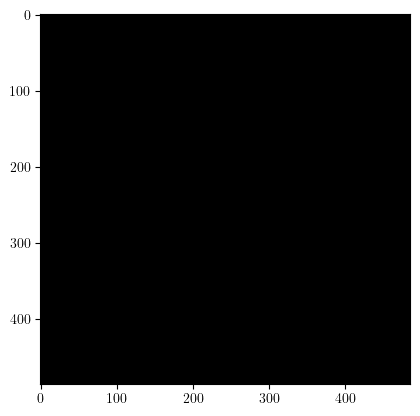

In [9]:
plt.imshow(matA, cmap="gray")

In [10]:
delta = 0.02 #There were 0.4 mm every 20 pixels. So, scaling, gives 0.02 mm per pixel
X = np.linspace(0, 486*delta + delta, 486)

In [11]:
np.max(X)

9.74

In [12]:
#The coordinates are in pixels, so they are integers and should be threated as that
#However, to be more exact, it will be better leave the x and y coordinates with decimals and then apply the 
#scale paratemer. So, this is only for give and idea, it is not correct to perform computations
df_img_pattern = np.floor(df).astype(int)

In [13]:
df_img_pattern.head(5)

,pos,x,y
0,1,42,249
1,2,67,167
2,3,66,192
3,4,66,217
4,5,67,243


In [14]:
df.head(5)

,pos,x,y
0,1,42.492971,249.695692
1,2,67.631579,167.676824
2,3,66.597279,192.662585
3,4,66.254289,217.381433
4,5,67.007501,243.505482


In [15]:
df.shape[0]

197

In [16]:
N = df.shape[0] #Number of centroids in the pattern
matA = np.zeros((486,486))

counter = 0 #Just to verify
for ii in range(0,N):
    matA[df_img_pattern["y"][ii]][df_img_pattern["x"][ii]] = 1
    counter += 1
counter    

matA[243][243] = 1

Text(0, 0.5, 'Height [pixels]')

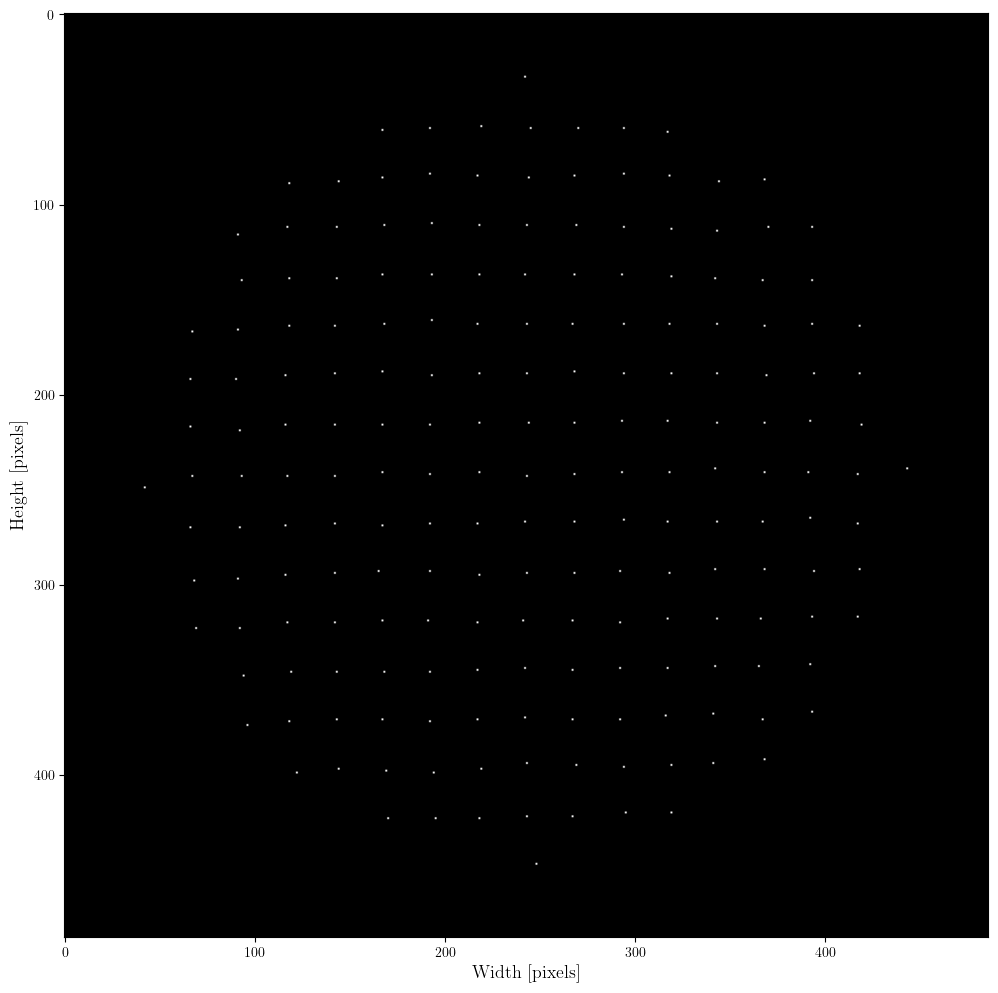

In [17]:
matA[243][243] = 1
plt.figure(figsize=(12,12))
plt.imshow(matA, cmap="gray")
plt.xlabel('Width [pixels]', size=13)
plt.ylabel('Height [pixels]', size=13)

In [18]:
matA.shape

(486, 486)

In [19]:
df["x_d"] = df["x"] * delta
df["y_d"] = df["y"] * delta

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197 entries, 0 to 196
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   pos     197 non-null    int64  
 1   x       197 non-null    float64
 2   y       197 non-null    float64
 3   x_d     197 non-null    float64
 4   y_d     197 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.8 KB


In [21]:
df.head(10)

,pos,x,y,x_d,y_d
0,1,42.492971,249.695692,0.849859,4.993914
1,2,67.631579,167.676824,1.352632,3.353536
2,3,66.597279,192.662585,1.331946,3.853252
3,4,66.254289,217.381433,1.325086,4.347629
4,5,67.007501,243.505482,1.340150,4.870110
5,6,66.757714,270.215478,1.335154,5.404310
6,7,68.196232,298.432496,1.363925,5.968650
7,8,69.211842,323.688581,1.384237,6.473772
8,9,91.981579,116.208772,1.839632,2.324175
9,10,93.135937,140.809375,1.862719,2.816187


In [22]:
mat_R_X = np.zeros((ncols,ncols))

In [23]:
# --- 17x17 Grid (197 points) - Sequential Indices 0-196 ---

mat_R_X[8][0] = df["x_d"][0]

mat_R_X[5][1] = df["x_d"][1]
mat_R_X[6][1] = df["x_d"][2]
mat_R_X[7][1] = df["x_d"][3]
mat_R_X[8][1] = df["x_d"][4]
mat_R_X[9][1] = df["x_d"][5]
mat_R_X[10][1] = df["x_d"][6]
mat_R_X[11][1] = df["x_d"][7]

mat_R_X[3][2] = df["x_d"][8]
mat_R_X[4][2] = df["x_d"][9]
mat_R_X[5][2] = df["x_d"][10]
mat_R_X[6][2] = df["x_d"][11]
mat_R_X[7][2] = df["x_d"][12]
mat_R_X[8][2] = df["x_d"][13]
mat_R_X[9][2] = df["x_d"][14]
mat_R_X[10][2] = df["x_d"][15]
mat_R_X[11][2] = df["x_d"][16]
mat_R_X[12][2] = df["x_d"][17]
mat_R_X[13][2] = df["x_d"][18]

mat_R_X[2][3] = df["x_d"][19]
mat_R_X[3][3] = df["x_d"][20]
mat_R_X[4][3] = df["x_d"][21]
mat_R_X[5][3] = df["x_d"][22]
mat_R_X[6][3] = df["x_d"][23]
mat_R_X[7][3] = df["x_d"][24]
mat_R_X[8][3] = df["x_d"][25]
mat_R_X[9][3] = df["x_d"][26]
mat_R_X[10][3] = df["x_d"][27]
mat_R_X[11][3] = df["x_d"][28]
mat_R_X[12][3] = df["x_d"][29]
mat_R_X[13][3] = df["x_d"][30]
mat_R_X[14][3] = df["x_d"][31]

mat_R_X[2][4] = df["x_d"][32]
mat_R_X[3][4] = df["x_d"][33]
mat_R_X[4][4] = df["x_d"][34]
mat_R_X[5][4] = df["x_d"][35]
mat_R_X[6][4] = df["x_d"][36]
mat_R_X[7][4] = df["x_d"][37]
mat_R_X[8][4] = df["x_d"][38]
mat_R_X[9][4] = df["x_d"][39]
mat_R_X[10][4] = df["x_d"][40]
mat_R_X[11][4] = df["x_d"][41]
mat_R_X[12][4] = df["x_d"][42]
mat_R_X[13][4] = df["x_d"][43]
mat_R_X[14][4] = df["x_d"][44]

# --- Start of the section that was your loop (indices 45-151) ---
# ii = 5 (Indices 45-59)
mat_R_X[1][5] = df["x_d"][45]
mat_R_X[2][5] = df["x_d"][46]
mat_R_X[3][5] = df["x_d"][47]
mat_R_X[4][5] = df["x_d"][48]
mat_R_X[5][5] = df["x_d"][49]
mat_R_X[6][5] = df["x_d"][50]
mat_R_X[7][5] = df["x_d"][51]
mat_R_X[8][5] = df["x_d"][52]
mat_R_X[9][5] = df["x_d"][53]
mat_R_X[10][5] = df["x_d"][54]
mat_R_X[11][5] = df["x_d"][55]
mat_R_X[12][5] = df["x_d"][56]
mat_R_X[13][5] = df["x_d"][57]
mat_R_X[14][5] = df["x_d"][58]
mat_R_X[15][5] = df["x_d"][59]

# ii = 6 (Indices 60-74)
mat_R_X[1][6] = df["x_d"][60]
mat_R_X[2][6] = df["x_d"][61]
mat_R_X[3][6] = df["x_d"][62]
mat_R_X[4][6] = df["x_d"][63]
mat_R_X[5][6] = df["x_d"][64]
mat_R_X[6][6] = df["x_d"][65]
mat_R_X[7][6] = df["x_d"][66]
mat_R_X[8][6] = df["x_d"][67]
mat_R_X[9][6] = df["x_d"][68]
mat_R_X[10][6] = df["x_d"][69]
mat_R_X[11][6] = df["x_d"][70]
mat_R_X[12][6] = df["x_d"][71]
mat_R_X[13][6] = df["x_d"][72]
mat_R_X[14][6] = df["x_d"][73]
mat_R_X[15][6] = df["x_d"][74]

# ii = 7 (Indices 75-89)
mat_R_X[1][7] = df["x_d"][75]
mat_R_X[2][7] = df["x_d"][76]
mat_R_X[3][7] = df["x_d"][77]
mat_R_X[4][7] = df["x_d"][78]
mat_R_X[5][7] = df["x_d"][79]
mat_R_X[6][7] = df["x_d"][80]
mat_R_X[7][7] = df["x_d"][81]
mat_R_X[8][7] = df["x_d"][82]
mat_R_X[9][7] = df["x_d"][83]
mat_R_X[10][7] = df["x_d"][84]
mat_R_X[11][7] = df["x_d"][85]
mat_R_X[12][7] = df["x_d"][86]
mat_R_X[13][7] = df["x_d"][87]
mat_R_X[14][7] = df["x_d"][88]
mat_R_X[15][7] = df["x_d"][89]

# ii = 8 (Indices 90-106)
mat_R_X[0][8] = df["x_d"][90]
mat_R_X[1][8] = df["x_d"][91]
mat_R_X[2][8] = df["x_d"][92]
mat_R_X[3][8] = df["x_d"][93]
mat_R_X[4][8] = df["x_d"][94]
mat_R_X[5][8] = df["x_d"][95]
mat_R_X[6][8] = df["x_d"][96]
mat_R_X[7][8] = df["x_d"][97]
mat_R_X[8][8] = df["x_d"][98]
mat_R_X[9][8] = df["x_d"][99]
mat_R_X[10][8] = df["x_d"][100]
mat_R_X[11][8] = df["x_d"][101]
mat_R_X[12][8] = df["x_d"][102]
mat_R_X[13][8] = df["x_d"][103]
mat_R_X[14][8] = df["x_d"][104]
mat_R_X[15][8] = df["x_d"][105]
mat_R_X[16][8] = df["x_d"][106]

# ii = 9 (Indices 107-121)
mat_R_X[1][9] = df["x_d"][107]
mat_R_X[2][9] = df["x_d"][108]
mat_R_X[3][9] = df["x_d"][109]
mat_R_X[4][9] = df["x_d"][110]
mat_R_X[5][9] = df["x_d"][111]
mat_R_X[6][9] = df["x_d"][112]
mat_R_X[7][9] = df["x_d"][113]
mat_R_X[8][9] = df["x_d"][114]
mat_R_X[9][9] = df["x_d"][115]
mat_R_X[10][9] = df["x_d"][116]
mat_R_X[11][9] = df["x_d"][117]
mat_R_X[12][9] = df["x_d"][118]
mat_R_X[13][9] = df["x_d"][119]
mat_R_X[14][9] = df["x_d"][120]
mat_R_X[15][9] = df["x_d"][121]

# ii = 10 (Indices 122-136)
mat_R_X[1][10] = df["x_d"][122]
mat_R_X[2][10] = df["x_d"][123]
mat_R_X[3][10] = df["x_d"][124]
mat_R_X[4][10] = df["x_d"][125]
mat_R_X[5][10] = df["x_d"][126]
mat_R_X[6][10] = df["x_d"][127]
mat_R_X[7][10] = df["x_d"][128]
mat_R_X[8][10] = df["x_d"][129]
mat_R_X[9][10] = df["x_d"][130]
mat_R_X[10][10] = df["x_d"][131]
mat_R_X[11][10] = df["x_d"][132]
mat_R_X[12][10] = df["x_d"][133]
mat_R_X[13][10] = df["x_d"][134]
mat_R_X[14][10] = df["x_d"][135]
mat_R_X[15][10] = df["x_d"][136]

# ii = 11 (Indices 137-151)
mat_R_X[1][11] = df["x_d"][137]
mat_R_X[2][11] = df["x_d"][138]
mat_R_X[3][11] = df["x_d"][139]
mat_R_X[4][11] = df["x_d"][140]
mat_R_X[5][11] = df["x_d"][141]
mat_R_X[6][11] = df["x_d"][142]
mat_R_X[7][11] = df["x_d"][143]
mat_R_X[8][11] = df["x_d"][144]
mat_R_X[9][11] = df["x_d"][145]
mat_R_X[10][11] = df["x_d"][146]
mat_R_X[11][11] = df["x_d"][147]
mat_R_X[12][11] = df["x_d"][148]
mat_R_X[13][11] = df["x_d"][149]
mat_R_X[14][11] = df["x_d"][150]
mat_R_X[15][11] = df["x_d"][151]
# --- End of the loop section ---

mat_R_X[2][12] = df["x_d"][152]
mat_R_X[3][12] = df["x_d"][153]
mat_R_X[4][12] = df["x_d"][154]
mat_R_X[5][12] = df["x_d"][155]
mat_R_X[6][12] = df["x_d"][156]
mat_R_X[7][12] = df["x_d"][157]
mat_R_X[8][12] = df["x_d"][158]
mat_R_X[9][12] = df["x_d"][159]
mat_R_X[10][12] = df["x_d"][160]
mat_R_X[11][12] = df["x_d"][161]
mat_R_X[12][12] = df["x_d"][162] 
mat_R_X[13][12] = df["x_d"][163]
mat_R_X[14][12] = df["x_d"][164]

mat_R_X[2][13] = df["x_d"][165]
mat_R_X[3][13] = df["x_d"][166]
mat_R_X[4][13] = df["x_d"][167]
mat_R_X[5][13] = df["x_d"][168]
mat_R_X[6][13] = df["x_d"][169]
mat_R_X[7][13] = df["x_d"][170]
mat_R_X[8][13] = df["x_d"][171]
mat_R_X[9][13] = df["x_d"][172]
mat_R_X[10][13] = df["x_d"][173]
mat_R_X[11][13] = df["x_d"][174]
mat_R_X[12][13] = df["x_d"][175]
mat_R_X[13][13] = df["x_d"][176]
mat_R_X[14][13] = df["x_d"][177]

mat_R_X[3][14] = df["x_d"][178]
mat_R_X[4][14] = df["x_d"][179]
mat_R_X[5][14] = df["x_d"][180]
mat_R_X[6][14] = df["x_d"][181]
mat_R_X[7][14] = df["x_d"][182]
mat_R_X[8][14] = df["x_d"][183]
mat_R_X[9][14] = df["x_d"][184]
mat_R_X[10][14] = df["x_d"][185]
mat_R_X[11][14] = df["x_d"][186]
mat_R_X[12][14] = df["x_d"][187]
mat_R_X[13][14] = df["x_d"][188]

mat_R_X[5][15] = df["x_d"][189]
mat_R_X[6][15] = df["x_d"][190]
mat_R_X[7][15] = df["x_d"][191]
mat_R_X[8][15] = df["x_d"][192]
mat_R_X[9][15] = df["x_d"][193]
mat_R_X[10][15] = df["x_d"][194]
mat_R_X[11][15] = df["x_d"][195]

mat_R_X[8][16] = df["x_d"][196]

Text(0.5, 1.0, 'X positions')

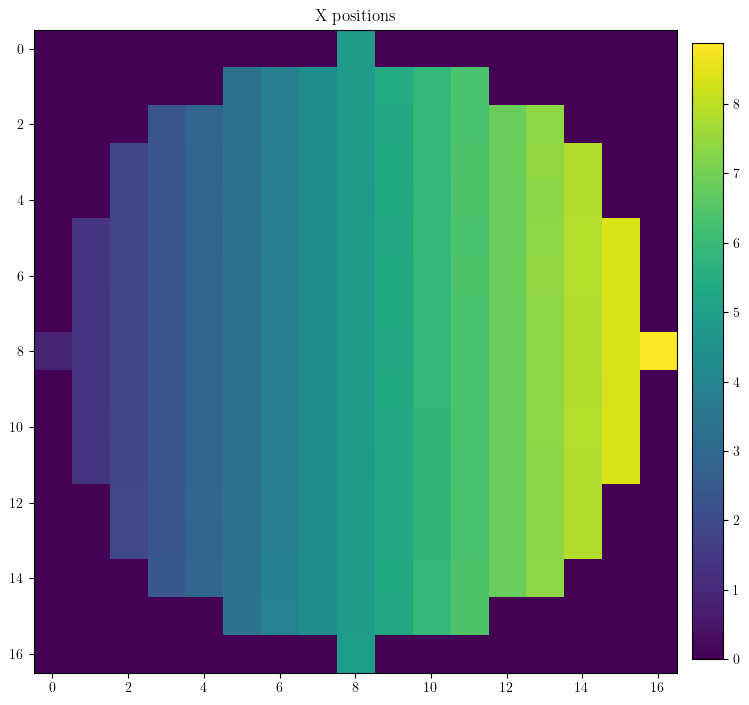

In [24]:
plt.figure(figsize=(10, 10))
im = plt.imshow(mat_R_X) 
cbar = plt.colorbar(im, shrink=0.8, pad=0.02) 
plt.title("X positions")

In [25]:
npmat_R_X = np.array(mat_R_X)

Now, we are going to stablish the Y positions, in order to compute the quantities in which we are interested in.

In [26]:
mat_R_Y = np.zeros((ncols,ncols))

In [27]:
# --- 17x17 Grid (197 points) - Sequential Indices 0-196 ---

mat_R_Y[8][0] = df["y_d"][0]

mat_R_Y[5][1] = df["y_d"][1]
mat_R_Y[6][1] = df["y_d"][2]
mat_R_Y[7][1] = df["y_d"][3]
mat_R_Y[8][1] = df["y_d"][4]
mat_R_Y[9][1] = df["y_d"][5]
mat_R_Y[10][1] = df["y_d"][6]
mat_R_Y[11][1] = df["y_d"][7]

mat_R_Y[3][2] = df["y_d"][8]
mat_R_Y[4][2] = df["y_d"][9]
mat_R_Y[5][2] = df["y_d"][10]
mat_R_Y[6][2] = df["y_d"][11]
mat_R_Y[7][2] = df["y_d"][12]
mat_R_Y[8][2] = df["y_d"][13]
mat_R_Y[9][2] = df["y_d"][14]
mat_R_Y[10][2] = df["y_d"][15]
mat_R_Y[11][2] = df["y_d"][16]
mat_R_Y[12][2] = df["y_d"][17]
mat_R_Y[13][2] = df["y_d"][18]

mat_R_Y[2][3] = df["y_d"][19]
mat_R_Y[3][3] = df["y_d"][20]
mat_R_Y[4][3] = df["y_d"][21]
mat_R_Y[5][3] = df["y_d"][22]
mat_R_Y[6][3] = df["y_d"][23]
mat_R_Y[7][3] = df["y_d"][24]
mat_R_Y[8][3] = df["y_d"][25]
mat_R_Y[9][3] = df["y_d"][26]
mat_R_Y[10][3] = df["y_d"][27]
mat_R_Y[11][3] = df["y_d"][28]
mat_R_Y[12][3] = df["y_d"][29]
mat_R_Y[13][3] = df["y_d"][30]
mat_R_Y[14][3] = df["y_d"][31]

mat_R_Y[2][4] = df["y_d"][32]
mat_R_Y[3][4] = df["y_d"][33]
mat_R_Y[4][4] = df["y_d"][34]
mat_R_Y[5][4] = df["y_d"][35]
mat_R_Y[6][4] = df["y_d"][36]
mat_R_Y[7][4] = df["y_d"][37]
mat_R_Y[8][4] = df["y_d"][38]
mat_R_Y[9][4] = df["y_d"][39]
mat_R_Y[10][4] = df["y_d"][40]
mat_R_Y[11][4] = df["y_d"][41]
mat_R_Y[12][4] = df["y_d"][42]
mat_R_Y[13][4] = df["y_d"][43]
mat_R_Y[14][4] = df["y_d"][44]

# --- Start of the section that was your loop (indices 45-151) ---
# ii = 5 (Indices 45-59)
mat_R_Y[1][5] = df["y_d"][45]
mat_R_Y[2][5] = df["y_d"][46]
mat_R_Y[3][5] = df["y_d"][47]
mat_R_Y[4][5] = df["y_d"][48]
mat_R_Y[5][5] = df["y_d"][49]
mat_R_Y[6][5] = df["y_d"][50]
mat_R_Y[7][5] = df["y_d"][51]
mat_R_Y[8][5] = df["y_d"][52]
mat_R_Y[9][5] = df["y_d"][53]
mat_R_Y[10][5] = df["y_d"][54]
mat_R_Y[11][5] = df["y_d"][55]
mat_R_Y[12][5] = df["y_d"][56]
mat_R_Y[13][5] = df["y_d"][57]
mat_R_Y[14][5] = df["y_d"][58]
mat_R_Y[15][5] = df["y_d"][59]

# ii = 6 (Indices 60-74)
mat_R_Y[1][6] = df["y_d"][60]
mat_R_Y[2][6] = df["y_d"][61]
mat_R_Y[3][6] = df["y_d"][62]
mat_R_Y[4][6] = df["y_d"][63]
mat_R_Y[5][6] = df["y_d"][64]
mat_R_Y[6][6] = df["y_d"][65]
mat_R_Y[7][6] = df["y_d"][66]
mat_R_Y[8][6] = df["y_d"][67]
mat_R_Y[9][6] = df["y_d"][68]
mat_R_Y[10][6] = df["y_d"][69]
mat_R_Y[11][6] = df["y_d"][70]
mat_R_Y[12][6] = df["y_d"][71]
mat_R_Y[13][6] = df["y_d"][72]
mat_R_Y[14][6] = df["y_d"][73]
mat_R_Y[15][6] = df["y_d"][74]

# ii = 7 (Indices 75-89)
mat_R_Y[1][7] = df["y_d"][75]
mat_R_Y[2][7] = df["y_d"][76]
mat_R_Y[3][7] = df["y_d"][77]
mat_R_Y[4][7] = df["y_d"][78]
mat_R_Y[5][7] = df["y_d"][79]
mat_R_Y[6][7] = df["y_d"][80]
mat_R_Y[7][7] = df["y_d"][81]
mat_R_Y[8][7] = df["y_d"][82]
mat_R_Y[9][7] = df["y_d"][83]
mat_R_Y[10][7] = df["y_d"][84]
mat_R_Y[11][7] = df["y_d"][85]
mat_R_Y[12][7] = df["y_d"][86]
mat_R_Y[13][7] = df["y_d"][87]
mat_R_Y[14][7] = df["y_d"][88]
mat_R_Y[15][7] = df["y_d"][89]

# ii = 8 (Indices 90-106)
mat_R_Y[0][8] = df["y_d"][90]
mat_R_Y[1][8] = df["y_d"][91]
mat_R_Y[2][8] = df["y_d"][92]
mat_R_Y[3][8] = df["y_d"][93]
mat_R_Y[4][8] = df["y_d"][94]
mat_R_Y[5][8] = df["y_d"][95]
mat_R_Y[6][8] = df["y_d"][96]
mat_R_Y[7][8] = df["y_d"][97]
mat_R_Y[8][8] = df["y_d"][98]
mat_R_Y[9][8] = df["y_d"][99]
mat_R_Y[10][8] = df["y_d"][100]
mat_R_Y[11][8] = df["y_d"][101]
mat_R_Y[12][8] = df["y_d"][102]
mat_R_Y[13][8] = df["y_d"][103]
mat_R_Y[14][8] = df["y_d"][104]
mat_R_Y[15][8] = df["y_d"][105]
mat_R_Y[16][8] = df["y_d"][106]

# ii = 9 (Indices 107-121)
mat_R_Y[1][9] = df["y_d"][107]
mat_R_Y[2][9] = df["y_d"][108]
mat_R_Y[3][9] = df["y_d"][109]
mat_R_Y[4][9] = df["y_d"][110]
mat_R_Y[5][9] = df["y_d"][111]
mat_R_Y[6][9] = df["y_d"][112]
mat_R_Y[7][9] = df["y_d"][113]
mat_R_Y[8][9] = df["y_d"][114]
mat_R_Y[9][9] = df["y_d"][115]
mat_R_Y[10][9] = df["y_d"][116]
mat_R_Y[11][9] = df["y_d"][117]
mat_R_Y[12][9] = df["y_d"][118]
mat_R_Y[13][9] = df["y_d"][119]
mat_R_Y[14][9] = df["y_d"][120]
mat_R_Y[15][9] = df["y_d"][121]

# ii = 10 (Indices 122-136)
mat_R_Y[1][10] = df["y_d"][122]
mat_R_Y[2][10] = df["y_d"][123]
mat_R_Y[3][10] = df["y_d"][124]
mat_R_Y[4][10] = df["y_d"][125]
mat_R_Y[5][10] = df["y_d"][126]
mat_R_Y[6][10] = df["y_d"][127]
mat_R_Y[7][10] = df["y_d"][128]
mat_R_Y[8][10] = df["y_d"][129]
mat_R_Y[9][10] = df["y_d"][130]
mat_R_Y[10][10] = df["y_d"][131]
mat_R_Y[11][10] = df["y_d"][132]
mat_R_Y[12][10] = df["y_d"][133]
mat_R_Y[13][10] = df["y_d"][134]
mat_R_Y[14][10] = df["y_d"][135]
mat_R_Y[15][10] = df["y_d"][136]

# ii = 11 (Indices 137-151)
mat_R_Y[1][11] = df["y_d"][137]
mat_R_Y[2][11] = df["y_d"][138]
mat_R_Y[3][11] = df["y_d"][139]
mat_R_Y[4][11] = df["y_d"][140]
mat_R_Y[5][11] = df["y_d"][141]
mat_R_Y[6][11] = df["y_d"][142]
mat_R_Y[7][11] = df["y_d"][143]
mat_R_Y[8][11] = df["y_d"][144]
mat_R_Y[9][11] = df["y_d"][145]
mat_R_Y[10][11] = df["y_d"][146]
mat_R_Y[11][11] = df["y_d"][147]
mat_R_Y[12][11] = df["y_d"][148]
mat_R_Y[13][11] = df["y_d"][149]
mat_R_Y[14][11] = df["y_d"][150]
mat_R_Y[15][11] = df["y_d"][151]
# --- End of the loop section ---

mat_R_Y[2][12] = df["y_d"][152]
mat_R_Y[3][12] = df["y_d"][153]
mat_R_Y[4][12] = df["y_d"][154]
mat_R_Y[5][12] = df["y_d"][155]
mat_R_Y[6][12] = df["y_d"][156]
mat_R_Y[7][12] = df["y_d"][157]
mat_R_Y[8][12] = df["y_d"][158]
mat_R_Y[9][12] = df["y_d"][159]
mat_R_Y[10][12] = df["y_d"][160]
mat_R_Y[11][12] = df["y_d"][161]
mat_R_Y[12][12] = df["y_d"][162] 
mat_R_Y[13][12] = df["y_d"][163]
mat_R_Y[14][12] = df["y_d"][164]

mat_R_Y[2][13] = df["y_d"][165]
mat_R_Y[3][13] = df["y_d"][166]
mat_R_Y[4][13] = df["y_d"][167]
mat_R_Y[5][13] = df["y_d"][168]
mat_R_Y[6][13] = df["y_d"][169]
mat_R_Y[7][13] = df["y_d"][170]
mat_R_Y[8][13] = df["y_d"][171]
mat_R_Y[9][13] = df["y_d"][172]
mat_R_Y[10][13] = df["y_d"][173]
mat_R_Y[11][13] = df["y_d"][174]
mat_R_Y[12][13] = df["y_d"][175]
mat_R_Y[13][13] = df["y_d"][176]
mat_R_Y[14][13] = df["y_d"][177]

mat_R_Y[3][14] = df["y_d"][178]
mat_R_Y[4][14] = df["y_d"][179]
mat_R_Y[5][14] = df["y_d"][180]
mat_R_Y[6][14] = df["y_d"][181]
mat_R_Y[7][14] = df["y_d"][182]
mat_R_Y[8][14] = df["y_d"][183]
mat_R_Y[9][14] = df["y_d"][184]
mat_R_Y[10][14] = df["y_d"][185]
mat_R_Y[11][14] = df["y_d"][186]
mat_R_Y[12][14] = df["y_d"][187]
mat_R_Y[13][14] = df["y_d"][188]

mat_R_Y[5][15] = df["y_d"][189]
mat_R_Y[6][15] = df["y_d"][190]
mat_R_Y[7][15] = df["y_d"][191]
mat_R_Y[8][15] = df["y_d"][192]
mat_R_Y[9][15] = df["y_d"][193]
mat_R_Y[10][15] = df["y_d"][194]
mat_R_Y[11][15] = df["y_d"][195]

mat_R_Y[8][16] = df["y_d"][196]

Text(0.5, 1.0, 'Y positions')

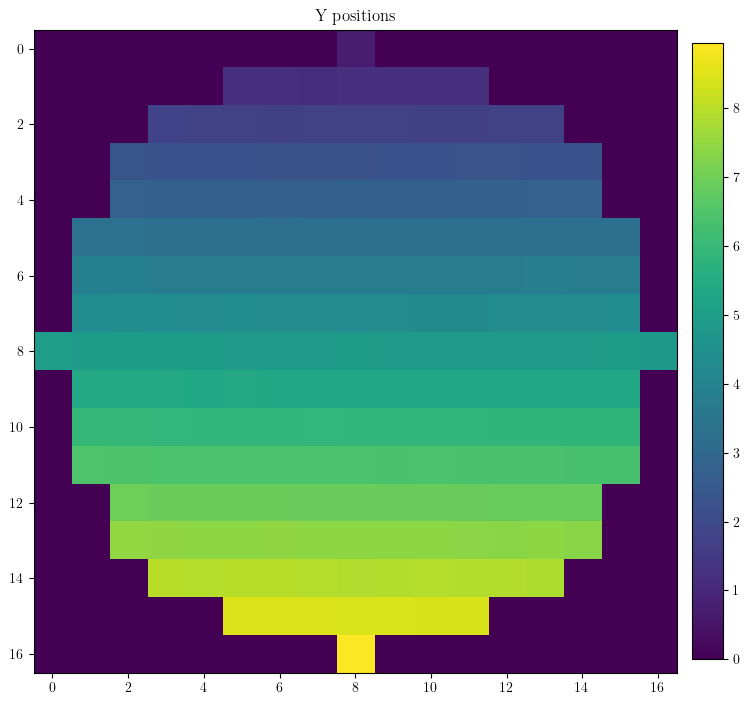

In [28]:
plt.figure(figsize=(10, 10))
im = plt.imshow(mat_R_Y) 
cbar = plt.colorbar(im, shrink=0.8, pad=0.02) 
plt.title("Y positions")

<center> <b>Analysis of the reference image</b> </center>

In [29]:
df_hpref = pd.read_csv('./../data/11-11-ref02.txt', delim_whitespace = True, header=None) #This is with the data coming from the machine learning algorithm
# df_hpref = pd.read_csv('output-that-works.txt', delim_whitespace = True, header=None)

C:\Users\PC\AppData\Local\Temp\ipykernel_6032\1319902371.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_hpref = pd.read_csv('./../data/11-11-ref02.txt', delim_whitespace = True, header=None) #This is with the data coming from the machine learning algorithm


In [30]:
df_hpref.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197 entries, 0 to 196
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       197 non-null    int64  
 1   1       197 non-null    float64
 2   2       197 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 4.7 KB


In [31]:
df_hpref.rename(columns={0:'pos', 2:'y', 1:'x'}, inplace=True)

In [32]:
df_hpref.head(3)

,pos,x,y
0,1,34.004467,241.936082
1,2,60.251120,158.916094
2,3,59.182005,184.469923


In [33]:
matA_hpref = np.zeros((486,486))

In [34]:
#This code corresponds to the scale stablished from pixels to distance. It is 0.02mm per pixel
delta = 0.02
X = np.linspace(0, 486*delta + delta, 486)

In [35]:
df_img_ref = np.floor(df_hpref).astype(int)

In [36]:
df_img_ref.head(5)

,pos,x,y
0,1,34,241
1,2,60,158
2,3,59,184
3,4,58,209
4,5,59,236


In [37]:
N = df_hpref.shape[0] #Number of centroids in the pattern

counter = 0 #Just to verify
for ii in range(0,N):
    matA_hpref[df_img_ref["y"][ii]][df_img_ref["x"][ii]] = 1
    counter += 1
counter 

197

Text(0, 0.5, 'Height [pixels]')

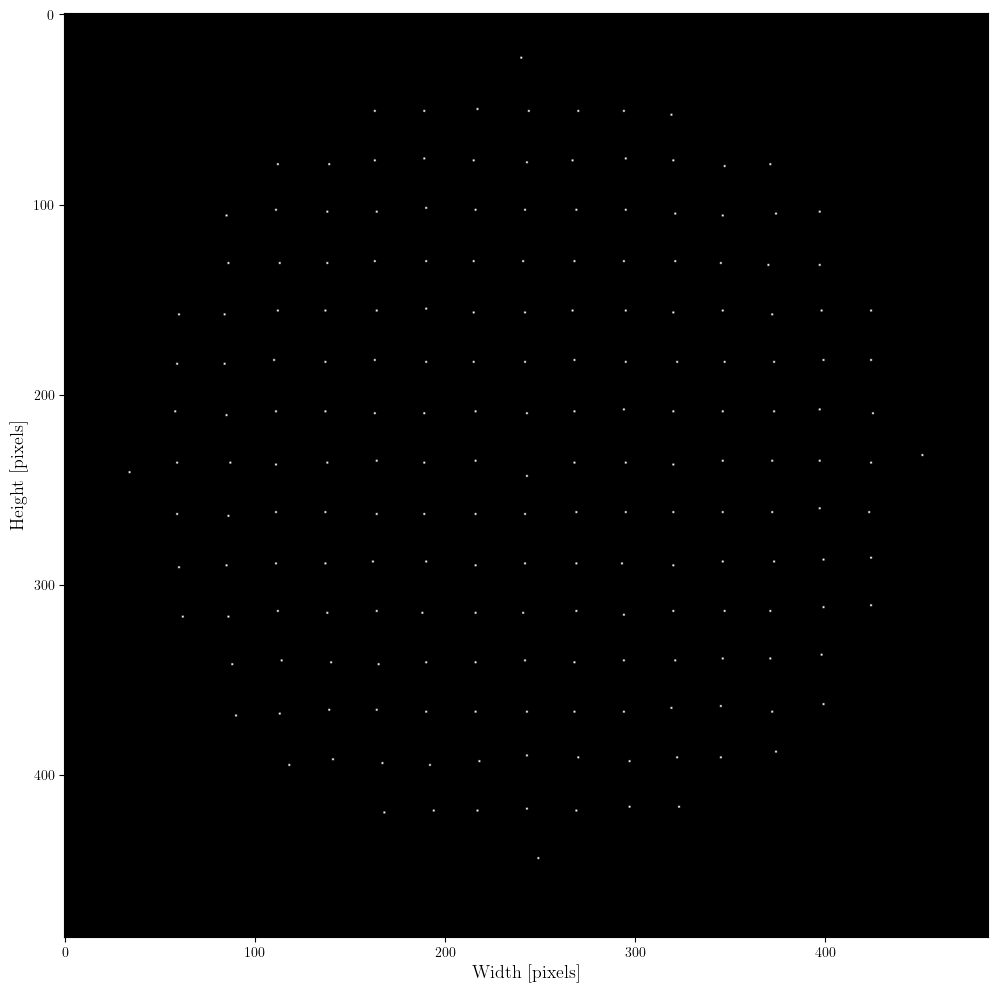

In [38]:
plt.figure(figsize=(12,12))
plt.imshow(matA_hpref, cmap="grey")
plt.xlabel('Width [pixels]', size=13)
plt.ylabel('Height [pixels]', size=13)

<center><b> Comparison between the pattern of points generated by reference surface and right eye <center><b>

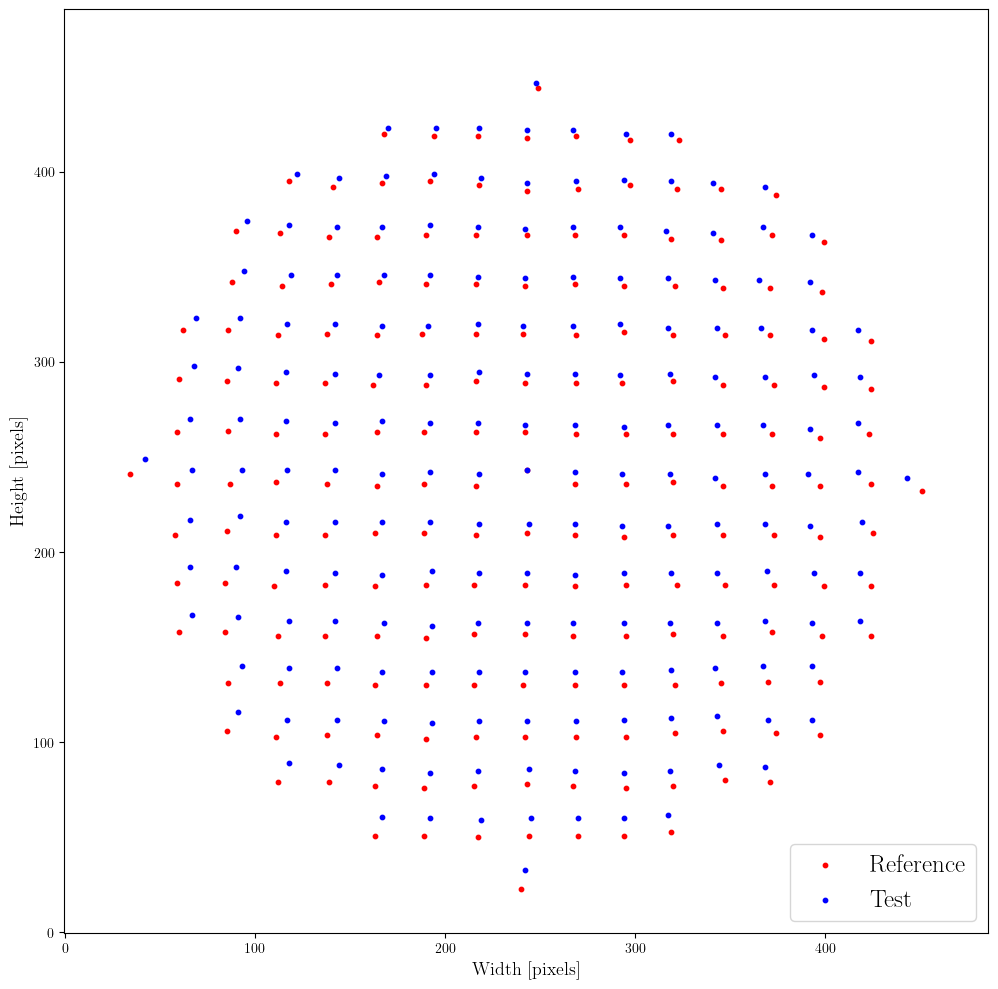

In [39]:
plt.figure(figsize=(12,12))

x1, y1 = np.nonzero(matA_hpref)  # rows, cols
y2, x2 = np.nonzero(matA)

plt.imshow(np.ones_like(matA), cmap="gray", vmin=0, vmax=1)

# Plot nonzero points as scatter
plt.scatter(y1, x1, c="red", s=10, label="Reference")   # s = markersize
plt.scatter(x2, y2, c="blue", s=10, label="Test")

plt.xlabel('Width [pixels]', size=13)
plt.ylabel('Height [pixels]', size=13)
plt.legend(fontsize=18, loc="lower right")
plt.gca().invert_yaxis()  # optional, to match image coordinates
plt.show()


In [40]:
df_hpref["x_d"] = df_hpref["x"] * delta
df_hpref["y_d"] = df_hpref["y"] * delta

In [41]:
df_hpref.head(10)

,pos,x,y,x_d,y_d
0,1,34.004467,241.936082,0.680089,4.838722
1,2,60.251120,158.916094,1.205022,3.178322
2,3,59.182005,184.469923,1.183640,3.689398
3,4,58.936978,209.483287,1.178740,4.189666
4,5,59.692090,236.024989,1.193842,4.720500
5,6,59.592770,263.103262,1.191855,5.262065
6,7,60.909788,291.922487,1.218196,5.838450
7,8,62.022038,317.512035,1.240441,6.350241
8,9,85.099974,106.999742,1.701999,2.139995
9,10,86.511364,131.913740,1.730227,2.638275


In [42]:
mat_R_X_hpref = np.zeros((ncols,ncols))

In [43]:
dasd = df_hpref[df_hpref["pos"]==1]["x_d"].values[0]
dasd

0.680089347

In [44]:
# --- 17x17 Grid (197 points) - Sequential pos 1-197 ---

mat_R_X_hpref[8][0] = df_hpref[df_hpref["pos"]==1]["x_d"].values[0]

mat_R_X_hpref[5][1] = df_hpref[df_hpref["pos"]==2]["x_d"].values[0]
mat_R_X_hpref[6][1] = df_hpref[df_hpref["pos"]==3]["x_d"].values[0]
mat_R_X_hpref[7][1] = df_hpref[df_hpref["pos"]==4]["x_d"].values[0]
mat_R_X_hpref[8][1] = df_hpref[df_hpref["pos"]==5]["x_d"].values[0]
mat_R_X_hpref[9][1] = df_hpref[df_hpref["pos"]==6]["x_d"].values[0]
mat_R_X_hpref[10][1] = df_hpref[df_hpref["pos"]==7]["x_d"].values[0]
mat_R_X_hpref[11][1] = df_hpref[df_hpref["pos"]==8]["x_d"].values[0]

mat_R_X_hpref[3][2] = df_hpref[df_hpref["pos"]==9]["x_d"].values[0]
mat_R_X_hpref[4][2] = df_hpref[df_hpref["pos"]==10]["x_d"].values[0]
mat_R_X_hpref[5][2] = df_hpref[df_hpref["pos"]==11]["x_d"].values[0]
mat_R_X_hpref[6][2] = df_hpref[df_hpref["pos"]==12]["x_d"].values[0]
mat_R_X_hpref[7][2] = df_hpref[df_hpref["pos"]==13]["x_d"].values[0]
mat_R_X_hpref[8][2] = df_hpref[df_hpref["pos"]==14]["x_d"].values[0]
mat_R_X_hpref[9][2] = df_hpref[df_hpref["pos"]==15]["x_d"].values[0]
mat_R_X_hpref[10][2] = df_hpref[df_hpref["pos"]==16]["x_d"].values[0]
mat_R_X_hpref[11][2] = df_hpref[df_hpref["pos"]==17]["x_d"].values[0]
mat_R_X_hpref[12][2] = df_hpref[df_hpref["pos"]==18]["x_d"].values[0]
mat_R_X_hpref[13][2] = df_hpref[df_hpref["pos"]==19]["x_d"].values[0]

mat_R_X_hpref[2][3] = df_hpref[df_hpref["pos"]==20]["x_d"].values[0]
mat_R_X_hpref[3][3] = df_hpref[df_hpref["pos"]==21]["x_d"].values[0]
mat_R_X_hpref[4][3] = df_hpref[df_hpref["pos"]==22]["x_d"].values[0]
mat_R_X_hpref[5][3] = df_hpref[df_hpref["pos"]==23]["x_d"].values[0]
mat_R_X_hpref[6][3] = df_hpref[df_hpref["pos"]==24]["x_d"].values[0]
mat_R_X_hpref[7][3] = df_hpref[df_hpref["pos"]==25]["x_d"].values[0]
mat_R_X_hpref[8][3] = df_hpref[df_hpref["pos"]==26]["x_d"].values[0]
mat_R_X_hpref[9][3] = df_hpref[df_hpref["pos"]==27]["x_d"].values[0]
mat_R_X_hpref[10][3] = df_hpref[df_hpref["pos"]==28]["x_d"].values[0]
mat_R_X_hpref[11][3] = df_hpref[df_hpref["pos"]==29]["x_d"].values[0]
mat_R_X_hpref[12][3] = df_hpref[df_hpref["pos"]==30]["x_d"].values[0]
mat_R_X_hpref[13][3] = df_hpref[df_hpref["pos"]==31]["x_d"].values[0]
mat_R_X_hpref[14][3] = df_hpref[df_hpref["pos"]==32]["x_d"].values[0]

mat_R_X_hpref[2][4] = df_hpref[df_hpref["pos"]==33]["x_d"].values[0]
mat_R_X_hpref[3][4] = df_hpref[df_hpref["pos"]==34]["x_d"].values[0]
mat_R_X_hpref[4][4] = df_hpref[df_hpref["pos"]==35]["x_d"].values[0]
mat_R_X_hpref[5][4] = df_hpref[df_hpref["pos"]==36]["x_d"].values[0]
mat_R_X_hpref[6][4] = df_hpref[df_hpref["pos"]==37]["x_d"].values[0]
mat_R_X_hpref[7][4] = df_hpref[df_hpref["pos"]==38]["x_d"].values[0]
mat_R_X_hpref[8][4] = df_hpref[df_hpref["pos"]==39]["x_d"].values[0]
mat_R_X_hpref[9][4] = df_hpref[df_hpref["pos"]==40]["x_d"].values[0]
mat_R_X_hpref[10][4] = df_hpref[df_hpref["pos"]==41]["x_d"].values[0]
mat_R_X_hpref[11][4] = df_hpref[df_hpref["pos"]==42]["x_d"].values[0]
mat_R_X_hpref[12][4] = df_hpref[df_hpref["pos"]==43]["x_d"].values[0]
mat_R_X_hpref[13][4] = df_hpref[df_hpref["pos"]==44]["x_d"].values[0]
mat_R_X_hpref[14][4] = df_hpref[df_hpref["pos"]==45]["x_d"].values[0]

# --- Column 5 (pos 46-60) ---
mat_R_X_hpref[1][5] = df_hpref[df_hpref["pos"]==46]["x_d"].values[0]
mat_R_X_hpref[2][5] = df_hpref[df_hpref["pos"]==47]["x_d"].values[0]
mat_R_X_hpref[3][5] = df_hpref[df_hpref["pos"]==48]["x_d"].values[0]
mat_R_X_hpref[4][5] = df_hpref[df_hpref["pos"]==49]["x_d"].values[0]
mat_R_X_hpref[5][5] = df_hpref[df_hpref["pos"]==50]["x_d"].values[0]
mat_R_X_hpref[6][5] = df_hpref[df_hpref["pos"]==51]["x_d"].values[0]
mat_R_X_hpref[7][5] = df_hpref[df_hpref["pos"]==52]["x_d"].values[0]
mat_R_X_hpref[8][5] = df_hpref[df_hpref["pos"]==53]["x_d"].values[0]
mat_R_X_hpref[9][5] = df_hpref[df_hpref["pos"]==54]["x_d"].values[0]
mat_R_X_hpref[10][5] = df_hpref[df_hpref["pos"]==55]["x_d"].values[0]
mat_R_X_hpref[11][5] = df_hpref[df_hpref["pos"]==56]["x_d"].values[0]
mat_R_X_hpref[12][5] = df_hpref[df_hpref["pos"]==57]["x_d"].values[0]
mat_R_X_hpref[13][5] = df_hpref[df_hpref["pos"]==58]["x_d"].values[0]
mat_R_X_hpref[14][5] = df_hpref[df_hpref["pos"]==59]["x_d"].values[0]
mat_R_X_hpref[15][5] = df_hpref[df_hpref["pos"]==60]["x_d"].values[0]

# --- Column 6 (pos 61-75) ---
mat_R_X_hpref[1][6] = df_hpref[df_hpref["pos"]==61]["x_d"].values[0]
mat_R_X_hpref[2][6] = df_hpref[df_hpref["pos"]==62]["x_d"].values[0]
mat_R_X_hpref[3][6] = df_hpref[df_hpref["pos"]==63]["x_d"].values[0]
mat_R_X_hpref[4][6] = df_hpref[df_hpref["pos"]==64]["x_d"].values[0]
mat_R_X_hpref[5][6] = df_hpref[df_hpref["pos"]==65]["x_d"].values[0]
mat_R_X_hpref[6][6] = df_hpref[df_hpref["pos"]==66]["x_d"].values[0]
mat_R_X_hpref[7][6] = df_hpref[df_hpref["pos"]==67]["x_d"].values[0]
mat_R_X_hpref[8][6] = df_hpref[df_hpref["pos"]==68]["x_d"].values[0]
mat_R_X_hpref[9][6] = df_hpref[df_hpref["pos"]==69]["x_d"].values[0]
mat_R_X_hpref[10][6] = df_hpref[df_hpref["pos"]==70]["x_d"].values[0]
mat_R_X_hpref[11][6] = df_hpref[df_hpref["pos"]==71]["x_d"].values[0]
mat_R_X_hpref[12][6] = df_hpref[df_hpref["pos"]==72]["x_d"].values[0]
mat_R_X_hpref[13][6] = df_hpref[df_hpref["pos"]==73]["x_d"].values[0]
mat_R_X_hpref[14][6] = df_hpref[df_hpref["pos"]==74]["x_d"].values[0]
mat_R_X_hpref[15][6] = df_hpref[df_hpref["pos"]==75]["x_d"].values[0]

# --- Column 7 (pos 76-90) ---
mat_R_X_hpref[1][7] = df_hpref[df_hpref["pos"]==76]["x_d"].values[0]
mat_R_X_hpref[2][7] = df_hpref[df_hpref["pos"]==77]["x_d"].values[0]
mat_R_X_hpref[3][7] = df_hpref[df_hpref["pos"]==78]["x_d"].values[0]
mat_R_X_hpref[4][7] = df_hpref[df_hpref["pos"]==79]["x_d"].values[0]
mat_R_X_hpref[5][7] = df_hpref[df_hpref["pos"]==80]["x_d"].values[0]
mat_R_X_hpref[6][7] = df_hpref[df_hpref["pos"]==81]["x_d"].values[0]
mat_R_X_hpref[7][7] = df_hpref[df_hpref["pos"]==82]["x_d"].values[0]
mat_R_X_hpref[8][7] = df_hpref[df_hpref["pos"]==83]["x_d"].values[0]
mat_R_X_hpref[9][7] = df_hpref[df_hpref["pos"]==84]["x_d"].values[0]
mat_R_X_hpref[10][7] = df_hpref[df_hpref["pos"]==85]["x_d"].values[0]
mat_R_X_hpref[11][7] = df_hpref[df_hpref["pos"]==86]["x_d"].values[0]
mat_R_X_hpref[12][7] = df_hpref[df_hpref["pos"]==87]["x_d"].values[0]
mat_R_X_hpref[13][7] = df_hpref[df_hpref["pos"]==88]["x_d"].values[0]
mat_R_X_hpref[14][7] = df_hpref[df_hpref["pos"]==89]["x_d"].values[0]
mat_R_X_hpref[15][7] = df_hpref[df_hpref["pos"]==90]["x_d"].values[0]

# --- Column 8 (Center Column, pos 91-107) ---
mat_R_X_hpref[0][8] = df_hpref[df_hpref["pos"]==91]["x_d"].values[0]
mat_R_X_hpref[1][8] = df_hpref[df_hpref["pos"]==92]["x_d"].values[0]
mat_R_X_hpref[2][8] = df_hpref[df_hpref["pos"]==93]["x_d"].values[0]
mat_R_X_hpref[3][8] = df_hpref[df_hpref["pos"]==94]["x_d"].values[0]
mat_R_X_hpref[4][8] = df_hpref[df_hpref["pos"]==95]["x_d"].values[0]
mat_R_X_hpref[5][8] = df_hpref[df_hpref["pos"]==96]["x_d"].values[0]
mat_R_X_hpref[6][8] = df_hpref[df_hpref["pos"]==97]["x_d"].values[0]
mat_R_X_hpref[7][8] = df_hpref[df_hpref["pos"]==98]["x_d"].values[0]
mat_R_X_hpref[8][8] = df_hpref[df_hpref["pos"]==99]["x_d"].values[0]
mat_R_X_hpref[9][8] = df_hpref[df_hpref["pos"]==100]["x_d"].values[0]
mat_R_X_hpref[10][8] = df_hpref[df_hpref["pos"]==101]["x_d"].values[0]
mat_R_X_hpref[11][8] = df_hpref[df_hpref["pos"]==102]["x_d"].values[0]
mat_R_X_hpref[12][8] = df_hpref[df_hpref["pos"]==103]["x_d"].values[0]
mat_R_X_hpref[13][8] = df_hpref[df_hpref["pos"]==104]["x_d"].values[0]
mat_R_X_hpref[14][8] = df_hpref[df_hpref["pos"]==105]["x_d"].values[0]
mat_R_X_hpref[15][8] = df_hpref[df_hpref["pos"]==106]["x_d"].values[0]
mat_R_X_hpref[16][8] = df_hpref[df_hpref["pos"]==107]["x_d"].values[0]

# --- Column 9 (pos 108-122) ---
mat_R_X_hpref[1][9] = df_hpref[df_hpref["pos"]==108]["x_d"].values[0]
mat_R_X_hpref[2][9] = df_hpref[df_hpref["pos"]==109]["x_d"].values[0]
mat_R_X_hpref[3][9] = df_hpref[df_hpref["pos"]==110]["x_d"].values[0]
mat_R_X_hpref[4][9] = df_hpref[df_hpref["pos"]==111]["x_d"].values[0]
mat_R_X_hpref[5][9] = df_hpref[df_hpref["pos"]==112]["x_d"].values[0]
mat_R_X_hpref[6][9] = df_hpref[df_hpref["pos"]==113]["x_d"].values[0]
mat_R_X_hpref[7][9] = df_hpref[df_hpref["pos"]==114]["x_d"].values[0]
mat_R_X_hpref[8][9] = df_hpref[df_hpref["pos"]==115]["x_d"].values[0]
mat_R_X_hpref[9][9] = df_hpref[df_hpref["pos"]==116]["x_d"].values[0]
mat_R_X_hpref[10][9] = df_hpref[df_hpref["pos"]==117]["x_d"].values[0]
mat_R_X_hpref[11][9] = df_hpref[df_hpref["pos"]==118]["x_d"].values[0]
mat_R_X_hpref[12][9] = df_hpref[df_hpref["pos"]==119]["x_d"].values[0]
mat_R_X_hpref[13][9] = df_hpref[df_hpref["pos"]==120]["x_d"].values[0]
mat_R_X_hpref[14][9] = df_hpref[df_hpref["pos"]==121]["x_d"].values[0]
mat_R_X_hpref[15][9] = df_hpref[df_hpref["pos"]==122]["x_d"].values[0]

# --- Column 10 (pos 123-137) ---
mat_R_X_hpref[1][10] = df_hpref[df_hpref["pos"]==123]["x_d"].values[0]
mat_R_X_hpref[2][10] = df_hpref[df_hpref["pos"]==124]["x_d"].values[0]
mat_R_X_hpref[3][10] = df_hpref[df_hpref["pos"]==125]["x_d"].values[0]
mat_R_X_hpref[4][10] = df_hpref[df_hpref["pos"]==126]["x_d"].values[0]
mat_R_X_hpref[5][10] = df_hpref[df_hpref["pos"]==127]["x_d"].values[0]
mat_R_X_hpref[6][10] = df_hpref[df_hpref["pos"]==128]["x_d"].values[0]
mat_R_X_hpref[7][10] = df_hpref[df_hpref["pos"]==129]["x_d"].values[0]
mat_R_X_hpref[8][10] = df_hpref[df_hpref["pos"]==130]["x_d"].values[0]
mat_R_X_hpref[9][10] = df_hpref[df_hpref["pos"]==131]["x_d"].values[0]
mat_R_X_hpref[10][10] = df_hpref[df_hpref["pos"]==132]["x_d"].values[0]
mat_R_X_hpref[11][10] = df_hpref[df_hpref["pos"]==133]["x_d"].values[0]
mat_R_X_hpref[12][10] = df_hpref[df_hpref["pos"]==134]["x_d"].values[0]
mat_R_X_hpref[13][10] = df_hpref[df_hpref["pos"]==135]["x_d"].values[0]
mat_R_X_hpref[14][10] = df_hpref[df_hpref["pos"]==136]["x_d"].values[0]
mat_R_X_hpref[15][10] = df_hpref[df_hpref["pos"]==137]["x_d"].values[0]

# --- Column 11 (pos 138-152) ---
mat_R_X_hpref[1][11] = df_hpref[df_hpref["pos"]==138]["x_d"].values[0]
mat_R_X_hpref[2][11] = df_hpref[df_hpref["pos"]==139]["x_d"].values[0]
mat_R_X_hpref[3][11] = df_hpref[df_hpref["pos"]==140]["x_d"].values[0]
mat_R_X_hpref[4][11] = df_hpref[df_hpref["pos"]==141]["x_d"].values[0]
mat_R_X_hpref[5][11] = df_hpref[df_hpref["pos"]==142]["x_d"].values[0]
mat_R_X_hpref[6][11] = df_hpref[df_hpref["pos"]==143]["x_d"].values[0]
mat_R_X_hpref[7][11] = df_hpref[df_hpref["pos"]==144]["x_d"].values[0]
mat_R_X_hpref[8][11] = df_hpref[df_hpref["pos"]==145]["x_d"].values[0]
mat_R_X_hpref[9][11] = df_hpref[df_hpref["pos"]==146]["x_d"].values[0]
mat_R_X_hpref[10][11] = df_hpref[df_hpref["pos"]==147]["x_d"].values[0]
mat_R_X_hpref[11][11] = df_hpref[df_hpref["pos"]==148]["x_d"].values[0]
mat_R_X_hpref[12][11] = df_hpref[df_hpref["pos"]==149]["x_d"].values[0]
mat_R_X_hpref[13][11] = df_hpref[df_hpref["pos"]==150]["x_d"].values[0]
mat_R_X_hpref[14][11] = df_hpref[df_hpref["pos"]==151]["x_d"].values[0]
mat_R_X_hpref[15][11] = df_hpref[df_hpref["pos"]==152]["x_d"].values[0]

# --- Column 12 (pos 153-165) ---
mat_R_X_hpref[2][12] = df_hpref[df_hpref["pos"]==153]["x_d"].values[0]
mat_R_X_hpref[3][12] = df_hpref[df_hpref["pos"]==154]["x_d"].values[0]
mat_R_X_hpref[4][12] = df_hpref[df_hpref["pos"]==155]["x_d"].values[0]
mat_R_X_hpref[5][12] = df_hpref[df_hpref["pos"]==156]["x_d"].values[0]
mat_R_X_hpref[6][12] = df_hpref[df_hpref["pos"]==157]["x_d"].values[0]
mat_R_X_hpref[7][12] = df_hpref[df_hpref["pos"]==158]["x_d"].values[0]
mat_R_X_hpref[8][12] = df_hpref[df_hpref["pos"]==159]["x_d"].values[0]
mat_R_X_hpref[9][12] = df_hpref[df_hpref["pos"]==160]["x_d"].values[0]
mat_R_X_hpref[10][12] = df_hpref[df_hpref["pos"]==161]["x_d"].values[0]
mat_R_X_hpref[11][12] = df_hpref[df_hpref["pos"]==162]["x_d"].values[0]
mat_R_X_hpref[12][12] = df_hpref[df_hpref["pos"]==163]["x_d"].values[0]
mat_R_X_hpref[13][12] = df_hpref[df_hpref["pos"]==164]["x_d"].values[0]
mat_R_X_hpref[14][12] = df_hpref[df_hpref["pos"]==165]["x_d"].values[0]

# --- Column 13 (pos 166-178) ---
mat_R_X_hpref[2][13] = df_hpref[df_hpref["pos"]==166]["x_d"].values[0]
mat_R_X_hpref[3][13] = df_hpref[df_hpref["pos"]==167]["x_d"].values[0]
mat_R_X_hpref[4][13] = df_hpref[df_hpref["pos"]==168]["x_d"].values[0]
mat_R_X_hpref[5][13] = df_hpref[df_hpref["pos"]==169]["x_d"].values[0]
mat_R_X_hpref[6][13] = df_hpref[df_hpref["pos"]==170]["x_d"].values[0]
mat_R_X_hpref[7][13] = df_hpref[df_hpref["pos"]==171]["x_d"].values[0]
mat_R_X_hpref[8][13] = df_hpref[df_hpref["pos"]==172]["x_d"].values[0]
mat_R_X_hpref[9][13] = df_hpref[df_hpref["pos"]==173]["x_d"].values[0]
mat_R_X_hpref[10][13] = df_hpref[df_hpref["pos"]==174]["x_d"].values[0]
mat_R_X_hpref[11][13] = df_hpref[df_hpref["pos"]==175]["x_d"].values[0]
mat_R_X_hpref[12][13] = df_hpref[df_hpref["pos"]==176]["x_d"].values[0]
mat_R_X_hpref[13][13] = df_hpref[df_hpref["pos"]==177]["x_d"].values[0]
mat_R_X_hpref[14][13] = df_hpref[df_hpref["pos"]==178]["x_d"].values[0]

# --- Column 14 (pos 179-189) ---
mat_R_X_hpref[3][14] = df_hpref[df_hpref["pos"]==179]["x_d"].values[0]
mat_R_X_hpref[4][14] = df_hpref[df_hpref["pos"]==180]["x_d"].values[0]
mat_R_X_hpref[5][14] = df_hpref[df_hpref["pos"]==181]["x_d"].values[0]
mat_R_X_hpref[6][14] = df_hpref[df_hpref["pos"]==182]["x_d"].values[0]
mat_R_X_hpref[7][14] = df_hpref[df_hpref["pos"]==183]["x_d"].values[0]
mat_R_X_hpref[8][14] = df_hpref[df_hpref["pos"]==184]["x_d"].values[0]
mat_R_X_hpref[9][14] = df_hpref[df_hpref["pos"]==185]["x_d"].values[0]
mat_R_X_hpref[10][14] = df_hpref[df_hpref["pos"]==186]["x_d"].values[0]
mat_R_X_hpref[11][14] = df_hpref[df_hpref["pos"]==187]["x_d"].values[0]
mat_R_X_hpref[12][14] = df_hpref[df_hpref["pos"]==188]["x_d"].values[0]
mat_R_X_hpref[13][14] = df_hpref[df_hpref["pos"]==189]["x_d"].values[0]

# --- Column 15 (pos 190-196) ---
mat_R_X_hpref[5][15] = df_hpref[df_hpref["pos"]==190]["x_d"].values[0]
mat_R_X_hpref[6][15] = df_hpref[df_hpref["pos"]==191]["x_d"].values[0]
mat_R_X_hpref[7][15] = df_hpref[df_hpref["pos"]==192]["x_d"].values[0]
mat_R_X_hpref[8][15] = df_hpref[df_hpref["pos"]==193]["x_d"].values[0]
mat_R_X_hpref[9][15] = df_hpref[df_hpref["pos"]==194]["x_d"].values[0]
mat_R_X_hpref[10][15] = df_hpref[df_hpref["pos"]==195]["x_d"].values[0]
mat_R_X_hpref[11][15] = df_hpref[df_hpref["pos"]==196]["x_d"].values[0]

# --- Column 16 (pos 197) ---
mat_R_X_hpref[8][16] = df_hpref[df_hpref["pos"]==197]["x_d"].values[0]

Text(0.5, 1.0, 'X positions reference')

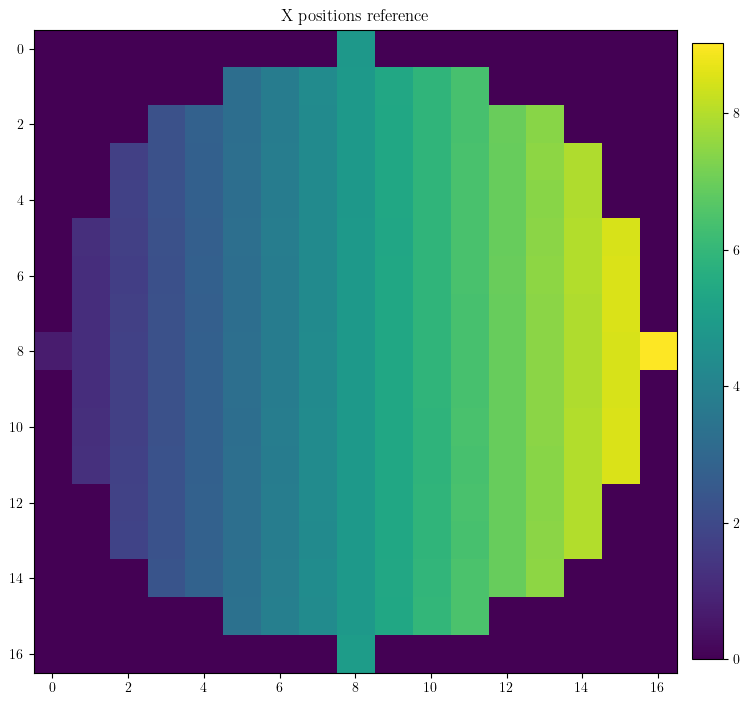

In [45]:
plt.figure(figsize=(10, 10))
im = plt.imshow(mat_R_X_hpref)
cbar = plt.colorbar(im, shrink=0.8, pad=0.02)
plt.title("X positions reference")

In [46]:
mat_R_Y_hpref = np.zeros((ncols,ncols))

In [47]:
# --- 17x17 Grid (197 points) - Sequential pos 1-197 ---
mat_R_Y_hpref[8][0] = df_hpref[df_hpref["pos"]==1]["y_d"].values[0]

mat_R_Y_hpref[5][1] = df_hpref[df_hpref["pos"]==2]["y_d"].values[0]
mat_R_Y_hpref[6][1] = df_hpref[df_hpref["pos"]==3]["y_d"].values[0]
mat_R_Y_hpref[7][1] = df_hpref[df_hpref["pos"]==4]["y_d"].values[0]
mat_R_Y_hpref[8][1] = df_hpref[df_hpref["pos"]==5]["y_d"].values[0]
mat_R_Y_hpref[9][1] = df_hpref[df_hpref["pos"]==6]["y_d"].values[0]
mat_R_Y_hpref[10][1] = df_hpref[df_hpref["pos"]==7]["y_d"].values[0]
mat_R_Y_hpref[11][1] = df_hpref[df_hpref["pos"]==8]["y_d"].values[0]

mat_R_Y_hpref[3][2] = df_hpref[df_hpref["pos"]==9]["y_d"].values[0]
mat_R_Y_hpref[4][2] = df_hpref[df_hpref["pos"]==10]["y_d"].values[0]
mat_R_Y_hpref[5][2] = df_hpref[df_hpref["pos"]==11]["y_d"].values[0]
mat_R_Y_hpref[6][2] = df_hpref[df_hpref["pos"]==12]["y_d"].values[0]
mat_R_Y_hpref[7][2] = df_hpref[df_hpref["pos"]==13]["y_d"].values[0]
mat_R_Y_hpref[8][2] = df_hpref[df_hpref["pos"]==14]["y_d"].values[0]
mat_R_Y_hpref[9][2] = df_hpref[df_hpref["pos"]==15]["y_d"].values[0]
mat_R_Y_hpref[10][2] = df_hpref[df_hpref["pos"]==16]["y_d"].values[0]
mat_R_Y_hpref[11][2] = df_hpref[df_hpref["pos"]==17]["y_d"].values[0]
mat_R_Y_hpref[12][2] = df_hpref[df_hpref["pos"]==18]["y_d"].values[0]
mat_R_Y_hpref[13][2] = df_hpref[df_hpref["pos"]==19]["y_d"].values[0]

mat_R_Y_hpref[2][3] = df_hpref[df_hpref["pos"]==20]["y_d"].values[0]
mat_R_Y_hpref[3][3] = df_hpref[df_hpref["pos"]==21]["y_d"].values[0]
mat_R_Y_hpref[4][3] = df_hpref[df_hpref["pos"]==22]["y_d"].values[0]
mat_R_Y_hpref[5][3] = df_hpref[df_hpref["pos"]==23]["y_d"].values[0]
mat_R_Y_hpref[6][3] = df_hpref[df_hpref["pos"]==24]["y_d"].values[0]
mat_R_Y_hpref[7][3] = df_hpref[df_hpref["pos"]==25]["y_d"].values[0]
mat_R_Y_hpref[8][3] = df_hpref[df_hpref["pos"]==26]["y_d"].values[0]
mat_R_Y_hpref[9][3] = df_hpref[df_hpref["pos"]==27]["y_d"].values[0]
mat_R_Y_hpref[10][3] = df_hpref[df_hpref["pos"]==28]["y_d"].values[0]
mat_R_Y_hpref[11][3] = df_hpref[df_hpref["pos"]==29]["y_d"].values[0]
mat_R_Y_hpref[12][3] = df_hpref[df_hpref["pos"]==30]["y_d"].values[0]
mat_R_Y_hpref[13][3] = df_hpref[df_hpref["pos"]==31]["y_d"].values[0]
mat_R_Y_hpref[14][3] = df_hpref[df_hpref["pos"]==32]["y_d"].values[0]

mat_R_Y_hpref[2][4] = df_hpref[df_hpref["pos"]==33]["y_d"].values[0]
mat_R_Y_hpref[3][4] = df_hpref[df_hpref["pos"]==34]["y_d"].values[0]
mat_R_Y_hpref[4][4] = df_hpref[df_hpref["pos"]==35]["y_d"].values[0]
mat_R_Y_hpref[5][4] = df_hpref[df_hpref["pos"]==36]["y_d"].values[0]
mat_R_Y_hpref[6][4] = df_hpref[df_hpref["pos"]==37]["y_d"].values[0]
mat_R_Y_hpref[7][4] = df_hpref[df_hpref["pos"]==38]["y_d"].values[0]
mat_R_Y_hpref[8][4] = df_hpref[df_hpref["pos"]==39]["y_d"].values[0]
mat_R_Y_hpref[9][4] = df_hpref[df_hpref["pos"]==40]["y_d"].values[0]
mat_R_Y_hpref[10][4] = df_hpref[df_hpref["pos"]==41]["y_d"].values[0]
mat_R_Y_hpref[11][4] = df_hpref[df_hpref["pos"]==42]["y_d"].values[0]
mat_R_Y_hpref[12][4] = df_hpref[df_hpref["pos"]==43]["y_d"].values[0]
mat_R_Y_hpref[13][4] = df_hpref[df_hpref["pos"]==44]["y_d"].values[0]
mat_R_Y_hpref[14][4] = df_hpref[df_hpref["pos"]==45]["y_d"].values[0]

# --- Column 5 (pos 46-60) ---
mat_R_Y_hpref[1][5] = df_hpref[df_hpref["pos"]==46]["y_d"].values[0]
mat_R_Y_hpref[2][5] = df_hpref[df_hpref["pos"]==47]["y_d"].values[0]
mat_R_Y_hpref[3][5] = df_hpref[df_hpref["pos"]==48]["y_d"].values[0]
mat_R_Y_hpref[4][5] = df_hpref[df_hpref["pos"]==49]["y_d"].values[0]
mat_R_Y_hpref[5][5] = df_hpref[df_hpref["pos"]==50]["y_d"].values[0]
mat_R_Y_hpref[6][5] = df_hpref[df_hpref["pos"]==51]["y_d"].values[0]
mat_R_Y_hpref[7][5] = df_hpref[df_hpref["pos"]==52]["y_d"].values[0]
mat_R_Y_hpref[8][5] = df_hpref[df_hpref["pos"]==53]["y_d"].values[0]
mat_R_Y_hpref[9][5] = df_hpref[df_hpref["pos"]==54]["y_d"].values[0]
mat_R_Y_hpref[10][5] = df_hpref[df_hpref["pos"]==55]["y_d"].values[0]
mat_R_Y_hpref[11][5] = df_hpref[df_hpref["pos"]==56]["y_d"].values[0]
mat_R_Y_hpref[12][5] = df_hpref[df_hpref["pos"]==57]["y_d"].values[0]
mat_R_Y_hpref[13][5] = df_hpref[df_hpref["pos"]==58]["y_d"].values[0]
mat_R_Y_hpref[14][5] = df_hpref[df_hpref["pos"]==59]["y_d"].values[0]
mat_R_Y_hpref[15][5] = df_hpref[df_hpref["pos"]==60]["y_d"].values[0]

# --- Column 6 (pos 61-75) ---
mat_R_Y_hpref[1][6] = df_hpref[df_hpref["pos"]==61]["y_d"].values[0]
mat_R_Y_hpref[2][6] = df_hpref[df_hpref["pos"]==62]["y_d"].values[0]
mat_R_Y_hpref[3][6] = df_hpref[df_hpref["pos"]==63]["y_d"].values[0]
mat_R_Y_hpref[4][6] = df_hpref[df_hpref["pos"]==64]["y_d"].values[0]
mat_R_Y_hpref[5][6] = df_hpref[df_hpref["pos"]==65]["y_d"].values[0]
mat_R_Y_hpref[6][6] = df_hpref[df_hpref["pos"]==66]["y_d"].values[0]
mat_R_Y_hpref[7][6] = df_hpref[df_hpref["pos"]==67]["y_d"].values[0]
mat_R_Y_hpref[8][6] = df_hpref[df_hpref["pos"]==68]["y_d"].values[0]
mat_R_Y_hpref[9][6] = df_hpref[df_hpref["pos"]==69]["y_d"].values[0]
mat_R_Y_hpref[10][6] = df_hpref[df_hpref["pos"]==70]["y_d"].values[0]
mat_R_Y_hpref[11][6] = df_hpref[df_hpref["pos"]==71]["y_d"].values[0]
mat_R_Y_hpref[12][6] = df_hpref[df_hpref["pos"]==72]["y_d"].values[0]
mat_R_Y_hpref[13][6] = df_hpref[df_hpref["pos"]==73]["y_d"].values[0]
mat_R_Y_hpref[14][6] = df_hpref[df_hpref["pos"]==74]["y_d"].values[0]
mat_R_Y_hpref[15][6] = df_hpref[df_hpref["pos"]==75]["y_d"].values[0]

# --- Column 7 (pos 76-90) ---
mat_R_Y_hpref[1][7] = df_hpref[df_hpref["pos"]==76]["y_d"].values[0]
mat_R_Y_hpref[2][7] = df_hpref[df_hpref["pos"]==77]["y_d"].values[0]
mat_R_Y_hpref[3][7] = df_hpref[df_hpref["pos"]==78]["y_d"].values[0]
mat_R_Y_hpref[4][7] = df_hpref[df_hpref["pos"]==79]["y_d"].values[0]
mat_R_Y_hpref[5][7] = df_hpref[df_hpref["pos"]==80]["y_d"].values[0]
mat_R_Y_hpref[6][7] = df_hpref[df_hpref["pos"]==81]["y_d"].values[0]
mat_R_Y_hpref[7][7] = df_hpref[df_hpref["pos"]==82]["y_d"].values[0]
mat_R_Y_hpref[8][7] = df_hpref[df_hpref["pos"]==83]["y_d"].values[0]
mat_R_Y_hpref[9][7] = df_hpref[df_hpref["pos"]==84]["y_d"].values[0]
mat_R_Y_hpref[10][7] = df_hpref[df_hpref["pos"]==85]["y_d"].values[0]
mat_R_Y_hpref[11][7] = df_hpref[df_hpref["pos"]==86]["y_d"].values[0]
mat_R_Y_hpref[12][7] = df_hpref[df_hpref["pos"]==87]["y_d"].values[0]
mat_R_Y_hpref[13][7] = df_hpref[df_hpref["pos"]==88]["y_d"].values[0]
mat_R_Y_hpref[14][7] = df_hpref[df_hpref["pos"]==89]["y_d"].values[0]
mat_R_Y_hpref[15][7] = df_hpref[df_hpref["pos"]==90]["y_d"].values[0]

# --- Column 8 (Center Column, pos 91-107) ---
mat_R_Y_hpref[0][8] = df_hpref[df_hpref["pos"]==91]["y_d"].values[0]
mat_R_Y_hpref[1][8] = df_hpref[df_hpref["pos"]==92]["y_d"].values[0]
mat_R_Y_hpref[2][8] = df_hpref[df_hpref["pos"]==93]["y_d"].values[0]
mat_R_Y_hpref[3][8] = df_hpref[df_hpref["pos"]==94]["y_d"].values[0]
mat_R_Y_hpref[4][8] = df_hpref[df_hpref["pos"]==95]["y_d"].values[0]
mat_R_Y_hpref[5][8] = df_hpref[df_hpref["pos"]==96]["y_d"].values[0]
mat_R_Y_hpref[6][8] = df_hpref[df_hpref["pos"]==97]["y_d"].values[0]
mat_R_Y_hpref[7][8] = df_hpref[df_hpref["pos"]==98]["y_d"].values[0]
mat_R_Y_hpref[8][8] = df_hpref[df_hpref["pos"]==99]["y_d"].values[0]
mat_R_Y_hpref[9][8] = df_hpref[df_hpref["pos"]==100]["y_d"].values[0]
mat_R_Y_hpref[10][8] = df_hpref[df_hpref["pos"]==101]["y_d"].values[0]
mat_R_Y_hpref[11][8] = df_hpref[df_hpref["pos"]==102]["y_d"].values[0]
mat_R_Y_hpref[12][8] = df_hpref[df_hpref["pos"]==103]["y_d"].values[0]
mat_R_Y_hpref[13][8] = df_hpref[df_hpref["pos"]==104]["y_d"].values[0]
mat_R_Y_hpref[14][8] = df_hpref[df_hpref["pos"]==105]["y_d"].values[0]
mat_R_Y_hpref[15][8] = df_hpref[df_hpref["pos"]==106]["y_d"].values[0]
mat_R_Y_hpref[16][8] = df_hpref[df_hpref["pos"]==107]["y_d"].values[0]

# --- Column 9 (pos 108-122) ---
mat_R_Y_hpref[1][9] = df_hpref[df_hpref["pos"]==108]["y_d"].values[0]
mat_R_Y_hpref[2][9] = df_hpref[df_hpref["pos"]==109]["y_d"].values[0]
mat_R_Y_hpref[3][9] = df_hpref[df_hpref["pos"]==110]["y_d"].values[0]
mat_R_Y_hpref[4][9] = df_hpref[df_hpref["pos"]==111]["y_d"].values[0]
mat_R_Y_hpref[5][9] = df_hpref[df_hpref["pos"]==112]["y_d"].values[0]
mat_R_Y_hpref[6][9] = df_hpref[df_hpref["pos"]==113]["y_d"].values[0]
mat_R_Y_hpref[7][9] = df_hpref[df_hpref["pos"]==114]["y_d"].values[0]
mat_R_Y_hpref[8][9] = df_hpref[df_hpref["pos"]==115]["y_d"].values[0]
mat_R_Y_hpref[9][9] = df_hpref[df_hpref["pos"]==116]["y_d"].values[0]
mat_R_Y_hpref[10][9] = df_hpref[df_hpref["pos"]==117]["y_d"].values[0]
mat_R_Y_hpref[11][9] = df_hpref[df_hpref["pos"]==118]["y_d"].values[0]
mat_R_Y_hpref[12][9] = df_hpref[df_hpref["pos"]==119]["y_d"].values[0]
mat_R_Y_hpref[13][9] = df_hpref[df_hpref["pos"]==120]["y_d"].values[0]
mat_R_Y_hpref[14][9] = df_hpref[df_hpref["pos"]==121]["y_d"].values[0]
mat_R_Y_hpref[15][9] = df_hpref[df_hpref["pos"]==122]["y_d"].values[0]

# --- Column 10 (pos 123-137) ---
mat_R_Y_hpref[1][10] = df_hpref[df_hpref["pos"]==123]["y_d"].values[0]
mat_R_Y_hpref[2][10] = df_hpref[df_hpref["pos"]==124]["y_d"].values[0]
mat_R_Y_hpref[3][10] = df_hpref[df_hpref["pos"]==125]["y_d"].values[0]
mat_R_Y_hpref[4][10] = df_hpref[df_hpref["pos"]==126]["y_d"].values[0]
mat_R_Y_hpref[5][10] = df_hpref[df_hpref["pos"]==127]["y_d"].values[0]
mat_R_Y_hpref[6][10] = df_hpref[df_hpref["pos"]==128]["y_d"].values[0]
mat_R_Y_hpref[7][10] = df_hpref[df_hpref["pos"]==129]["y_d"].values[0]
mat_R_Y_hpref[8][10] = df_hpref[df_hpref["pos"]==130]["y_d"].values[0]
mat_R_Y_hpref[9][10] = df_hpref[df_hpref["pos"]==131]["y_d"].values[0]
mat_R_Y_hpref[10][10] = df_hpref[df_hpref["pos"]==132]["y_d"].values[0]
mat_R_Y_hpref[11][10] = df_hpref[df_hpref["pos"]==133]["y_d"].values[0]
mat_R_Y_hpref[12][10] = df_hpref[df_hpref["pos"]==134]["y_d"].values[0]
mat_R_Y_hpref[13][10] = df_hpref[df_hpref["pos"]==135]["y_d"].values[0]
mat_R_Y_hpref[14][10] = df_hpref[df_hpref["pos"]==136]["y_d"].values[0]
mat_R_Y_hpref[15][10] = df_hpref[df_hpref["pos"]==137]["y_d"].values[0]

# --- Column 11 (pos 138-152) ---
mat_R_Y_hpref[1][11] = df_hpref[df_hpref["pos"]==138]["y_d"].values[0]
mat_R_Y_hpref[2][11] = df_hpref[df_hpref["pos"]==139]["y_d"].values[0]
mat_R_Y_hpref[3][11] = df_hpref[df_hpref["pos"]==140]["y_d"].values[0]
mat_R_Y_hpref[4][11] = df_hpref[df_hpref["pos"]==141]["y_d"].values[0]
mat_R_Y_hpref[5][11] = df_hpref[df_hpref["pos"]==142]["y_d"].values[0]
mat_R_Y_hpref[6][11] = df_hpref[df_hpref["pos"]==143]["y_d"].values[0]
mat_R_Y_hpref[7][11] = df_hpref[df_hpref["pos"]==144]["y_d"].values[0]
mat_R_Y_hpref[8][11] = df_hpref[df_hpref["pos"]==145]["y_d"].values[0]
mat_R_Y_hpref[9][11] = df_hpref[df_hpref["pos"]==146]["y_d"].values[0]
mat_R_Y_hpref[10][11] = df_hpref[df_hpref["pos"]==147]["y_d"].values[0]
mat_R_Y_hpref[11][11] = df_hpref[df_hpref["pos"]==148]["y_d"].values[0]
mat_R_Y_hpref[12][11] = df_hpref[df_hpref["pos"]==149]["y_d"].values[0]
mat_R_Y_hpref[13][11] = df_hpref[df_hpref["pos"]==150]["y_d"].values[0]
mat_R_Y_hpref[14][11] = df_hpref[df_hpref["pos"]==151]["y_d"].values[0]
mat_R_Y_hpref[15][11] = df_hpref[df_hpref["pos"]==152]["y_d"].values[0]

# --- Column 12 (pos 153-165) ---
mat_R_Y_hpref[2][12] = df_hpref[df_hpref["pos"]==153]["y_d"].values[0]
mat_R_Y_hpref[3][12] = df_hpref[df_hpref["pos"]==154]["y_d"].values[0]
mat_R_Y_hpref[4][12] = df_hpref[df_hpref["pos"]==155]["y_d"].values[0]
mat_R_Y_hpref[5][12] = df_hpref[df_hpref["pos"]==156]["y_d"].values[0]
mat_R_Y_hpref[6][12] = df_hpref[df_hpref["pos"]==157]["y_d"].values[0]
mat_R_Y_hpref[7][12] = df_hpref[df_hpref["pos"]==158]["y_d"].values[0]
mat_R_Y_hpref[8][12] = df_hpref[df_hpref["pos"]==159]["y_d"].values[0]
mat_R_Y_hpref[9][12] = df_hpref[df_hpref["pos"]==160]["y_d"].values[0]
mat_R_Y_hpref[10][12] = df_hpref[df_hpref["pos"]==161]["y_d"].values[0]
mat_R_Y_hpref[11][12] = df_hpref[df_hpref["pos"]==162]["y_d"].values[0]
mat_R_Y_hpref[12][12] = df_hpref[df_hpref["pos"]==163]["y_d"].values[0]
mat_R_Y_hpref[13][12] = df_hpref[df_hpref["pos"]==164]["y_d"].values[0]
mat_R_Y_hpref[14][12] = df_hpref[df_hpref["pos"]==165]["y_d"].values[0]

# --- Column 13 (pos 166-178) ---
mat_R_Y_hpref[2][13] = df_hpref[df_hpref["pos"]==166]["y_d"].values[0]
mat_R_Y_hpref[3][13] = df_hpref[df_hpref["pos"]==167]["y_d"].values[0]
mat_R_Y_hpref[4][13] = df_hpref[df_hpref["pos"]==168]["y_d"].values[0]
mat_R_Y_hpref[5][13] = df_hpref[df_hpref["pos"]==169]["y_d"].values[0]
mat_R_Y_hpref[6][13] = df_hpref[df_hpref["pos"]==170]["y_d"].values[0]
mat_R_Y_hpref[7][13] = df_hpref[df_hpref["pos"]==171]["y_d"].values[0]
mat_R_Y_hpref[8][13] = df_hpref[df_hpref["pos"]==172]["y_d"].values[0]
mat_R_Y_hpref[9][13] = df_hpref[df_hpref["pos"]==173]["y_d"].values[0]
mat_R_Y_hpref[10][13] = df_hpref[df_hpref["pos"]==174]["y_d"].values[0]
mat_R_Y_hpref[11][13] = df_hpref[df_hpref["pos"]==175]["y_d"].values[0]
mat_R_Y_hpref[12][13] = df_hpref[df_hpref["pos"]==176]["y_d"].values[0]
mat_R_Y_hpref[13][13] = df_hpref[df_hpref["pos"]==177]["y_d"].values[0]
mat_R_Y_hpref[14][13] = df_hpref[df_hpref["pos"]==178]["y_d"].values[0]

# --- Column 14 (pos 179-189) ---
mat_R_Y_hpref[3][14] = df_hpref[df_hpref["pos"]==179]["y_d"].values[0]
mat_R_Y_hpref[4][14] = df_hpref[df_hpref["pos"]==180]["y_d"].values[0]
mat_R_Y_hpref[5][14] = df_hpref[df_hpref["pos"]==181]["y_d"].values[0]
mat_R_Y_hpref[6][14] = df_hpref[df_hpref["pos"]==182]["y_d"].values[0]
mat_R_Y_hpref[7][14] = df_hpref[df_hpref["pos"]==183]["y_d"].values[0]
mat_R_Y_hpref[8][14] = df_hpref[df_hpref["pos"]==184]["y_d"].values[0]
mat_R_Y_hpref[9][14] = df_hpref[df_hpref["pos"]==185]["y_d"].values[0]
mat_R_Y_hpref[10][14] = df_hpref[df_hpref["pos"]==186]["y_d"].values[0]
mat_R_Y_hpref[11][14] = df_hpref[df_hpref["pos"]==187]["y_d"].values[0]
mat_R_Y_hpref[12][14] = df_hpref[df_hpref["pos"]==188]["y_d"].values[0]
mat_R_Y_hpref[13][14] = df_hpref[df_hpref["pos"]==189]["y_d"].values[0]

# --- Column 15 (pos 190-196) ---
mat_R_Y_hpref[5][15] = df_hpref[df_hpref["pos"]==190]["y_d"].values[0]
mat_R_Y_hpref[6][15] = df_hpref[df_hpref["pos"]==191]["y_d"].values[0]
mat_R_Y_hpref[7][15] = df_hpref[df_hpref["pos"]==192]["y_d"].values[0]
mat_R_Y_hpref[8][15] = df_hpref[df_hpref["pos"]==193]["y_d"].values[0]
mat_R_Y_hpref[9][15] = df_hpref[df_hpref["pos"]==194]["y_d"].values[0]
mat_R_Y_hpref[10][15] = df_hpref[df_hpref["pos"]==195]["y_d"].values[0]
mat_R_Y_hpref[11][15] = df_hpref[df_hpref["pos"]==196]["y_d"].values[0]

# --- Column 16 (pos 197) ---
mat_R_Y_hpref[8][16] = df_hpref[df_hpref["pos"]==197]["y_d"].values[0]

Text(0.5, 1.0, 'Y positions')

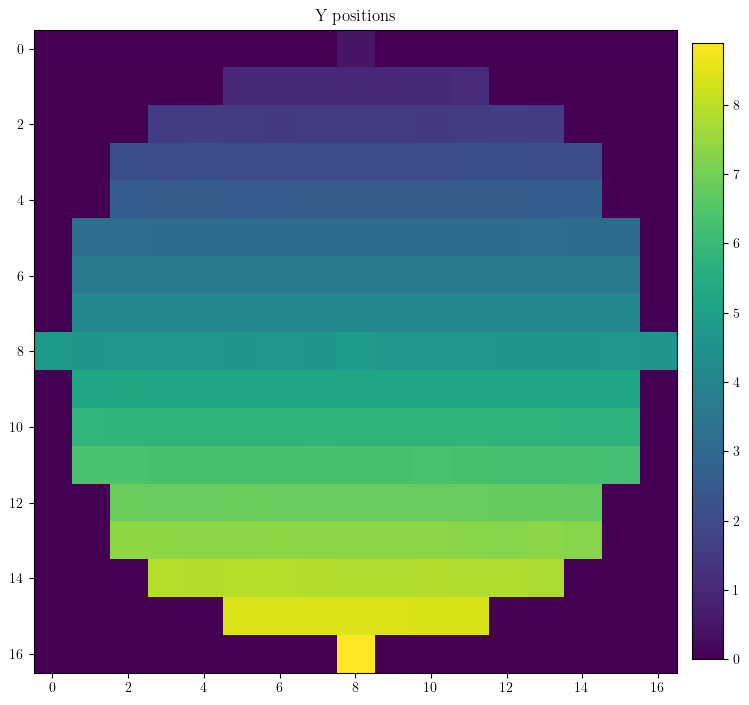

In [48]:
plt.figure(figsize=(10, 10))
im = plt.imshow(mat_R_Y_hpref)
cbar = plt.colorbar(im, shrink=0.8, pad=0.02)
plt.title("Y positions")

<b>                 ---------------------------------------------------------------------------------------------------------------- </b>

<h1><center> <b> Astigmatism </b></center><h1>

Now, we are going to iterate across the whole matrix and implement the algorithm to find the **astigmatism** in each point (those one that are meaningfull for us and the algorithm works)

In [49]:
mat_C = np.zeros((ncols,ncols))

In [50]:
ro = 0.4 #We passed from milimeters to meters
R = 7.78 #We passed from milimeters to meters
for ii in range(1,ncols-1): #This limits were stablished in order to avoid violating the range in which the matrix is defined
    for jj in range(1,ncols-1):
        x_looking = mat_R_X[ii-1][jj] != 0 and mat_R_X[ii+1][jj]!=0 and mat_R_X[ii][jj+1]!=0 and mat_R_X[ii][jj-1]!=0
        y_looking = mat_R_Y[ii-1][jj] != 0 and mat_R_Y[ii+1][jj]!=0 and mat_R_Y[ii][jj+1]!=0 and mat_R_Y[ii][jj-1]!=0
        if ((mat_R_X[ii][jj]!=0 and mat_R_Y[ii][jj]!= 0) and x_looking and y_looking):
            center_x_coord = mat_R_X_hpref[ii][jj]
            delta_x_a = mat_R_X[ii+1][jj] - mat_R_X_hpref[ii+1][jj]
            delta_x_b = mat_R_X[ii][jj+1] - mat_R_X_hpref[ii][jj+1]
            delta_x_c = mat_R_X[ii-1][jj] - mat_R_X_hpref[ii-1][jj]
            delta_x_d = mat_R_X[ii][jj-1] - mat_R_X_hpref[ii][jj-1]

            center_y_coord = mat_R_Y[ii][jj]
            delta_y_a = mat_R_Y[ii+1][jj] - mat_R_Y_hpref[ii+1][jj]
            delta_y_b = mat_R_Y[ii][jj+1] - mat_R_Y_hpref[ii][jj+1]
            delta_y_d = mat_R_Y[ii][jj-1] - mat_R_Y_hpref[ii][jj-1]

            first_factor = ((delta_x_a-delta_x_c) -(delta_y_b - delta_y_d))/(2*ro*R)
            second_factor = ((delta_x_b-delta_x_d)-(delta_y_a - delta_y_b))/(2*ro*R)

            C = (first_factor**2 + second_factor**2)**(1/2)

            mat_C[ii][jj] = C

(-0.5, 16.5, 16.5, -0.5)

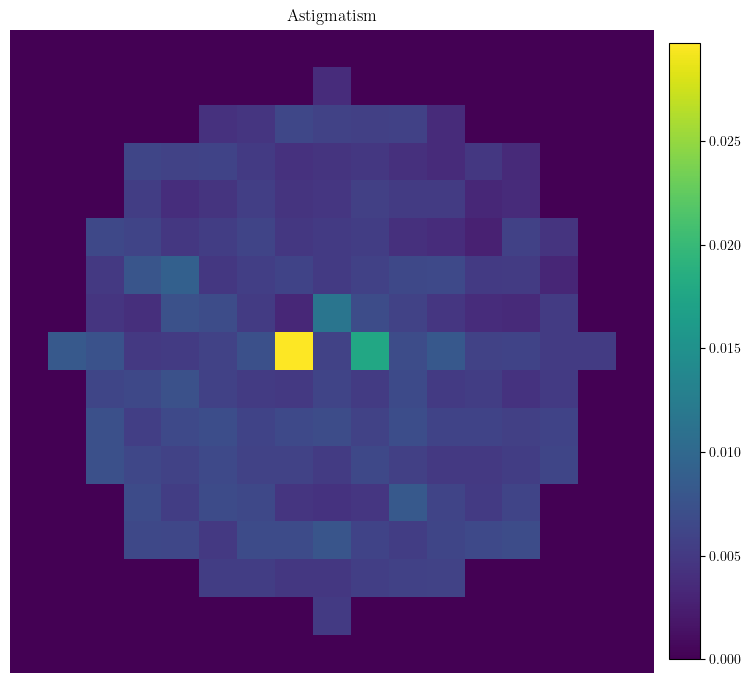

In [51]:
plt.figure(figsize=(10, 10))
im = plt.imshow(mat_C, cmap="viridis") 
cbar = plt.colorbar(im, shrink=0.8, pad=0.02) 
plt.title("Astigmatism")
plt.axis('off')

<h1><center><b>Minimum Curvature Lines</b><center></h1>

In [52]:
mat_Angles = np.zeros((ncols, ncols))

In [53]:
ro = 0.4 #We passed from milimeters to meters
R = 7.78 #We passed from milimeters to meters
for ii in range(1,ncols-1): #This limits were stablished in order to avoid violating the range in which the matrix is defined
    for jj in range(1,ncols-1):
        x_looking = mat_R_X[ii-1][jj] != 0 and mat_R_X[ii+1][jj]!=0 and mat_R_X[ii][jj+1]!=0 and mat_R_X[ii][jj-1]!=0
        y_looking = mat_R_Y[ii-1][jj] != 0 and mat_R_Y[ii+1][jj]!=0 and mat_R_Y[ii][jj+1]!=0 and mat_R_Y[ii][jj-1]!=0
        if ((mat_R_X[ii][jj]!=0 and mat_R_Y[ii][jj]!= 0) and x_looking and y_looking):
            center_x_coord = mat_R_X_hpref[ii][jj]
            delta_x_a = mat_R_X[ii+1][jj] - mat_R_X_hpref[ii+1][jj]
            delta_x_b = mat_R_X[ii][jj+1] - mat_R_X_hpref[ii][jj+1]
            delta_x_c = mat_R_X[ii-1][jj] - mat_R_X_hpref[ii-1][jj]
            delta_x_d = mat_R_X[ii][jj-1] - mat_R_X_hpref[ii][jj-1]

            center_y_coord = mat_R_Y[ii][jj]
            delta_y_a = mat_R_Y[ii+1][jj] - mat_R_Y_hpref[ii+1][jj]
            delta_y_b = mat_R_Y[ii][jj+1] - mat_R_Y_hpref[ii][jj+1]
            delta_y_d = mat_R_Y[ii][jj-1] - mat_R_Y_hpref[ii][jj-1]

            
            A = (delta_x_b-delta_x_d+delta_y_a-delta_y_b)/(delta_x_a-delta_x_c-delta_y_b+delta_y_d)


            mat_Angles[ii][jj] = 0.5*np.arctan(A)

Text(0.5, 1.0, 'Minimum Curvature Lines (Angles)')

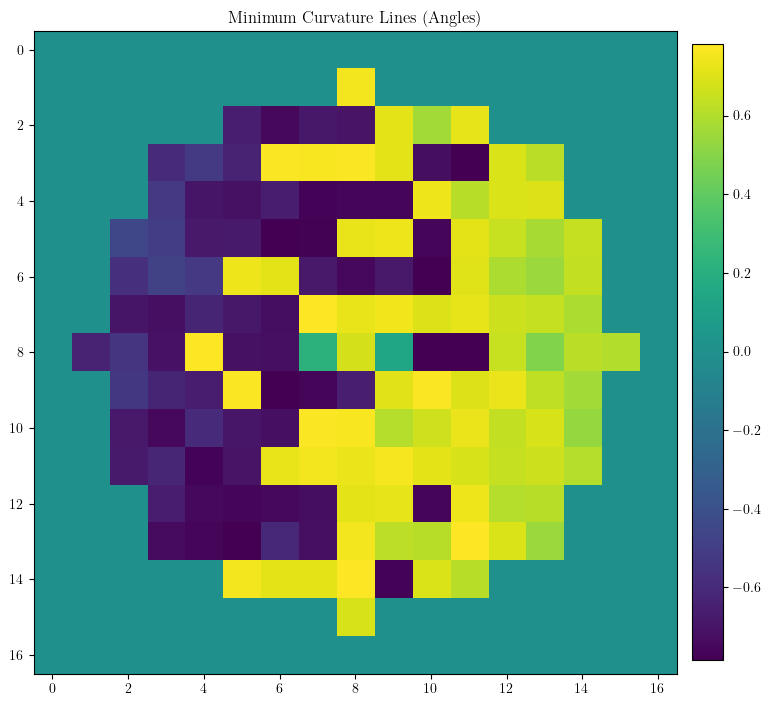

In [54]:
plt.figure(figsize=(10, 10))
im = plt.imshow(mat_Angles, cmap='viridis') 
cbar = plt.colorbar(im, shrink=0.8, pad=0.02) 
plt.title("Minimum Curvature Lines (Angles)")
# plt.axis('off')

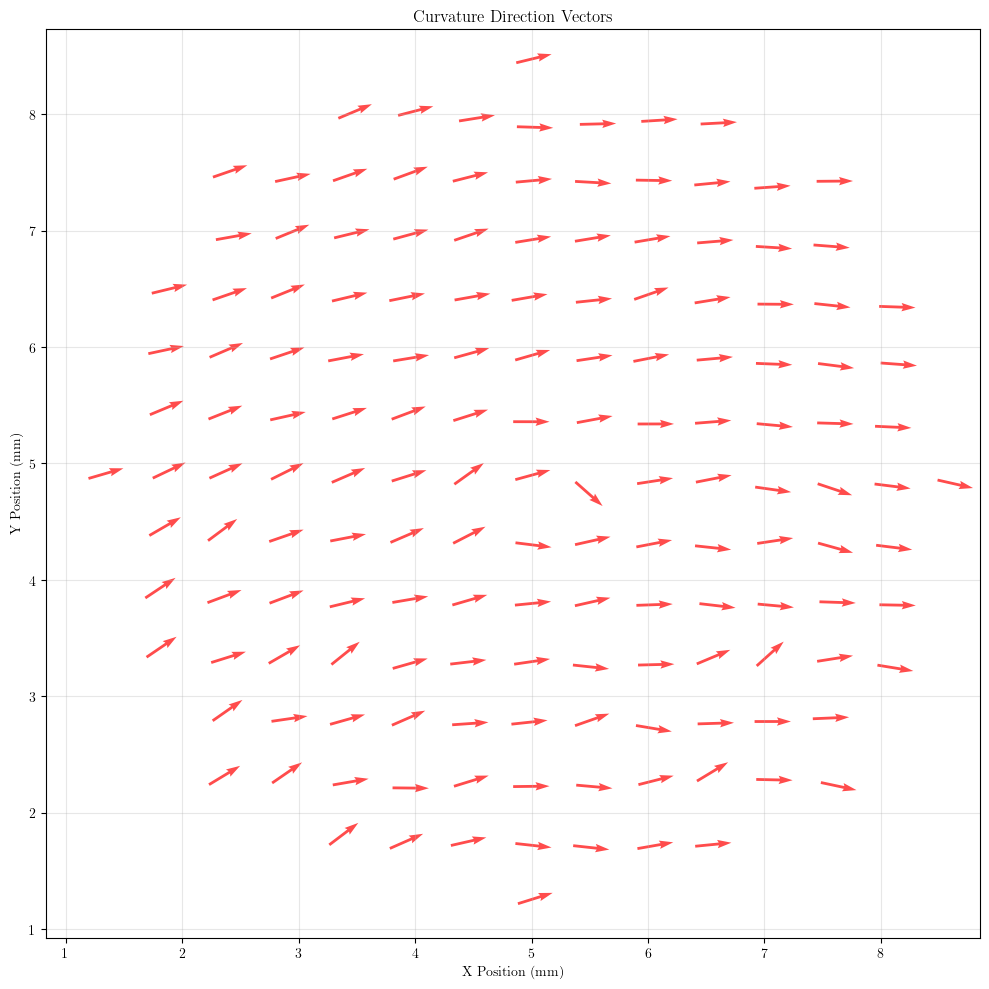

In [55]:
# --- Assume mat_R_X, mat_R_Y, mat_R_X_hpref, mat_R_Y_hpref are 19x19 arrays ---

# Your existing setup
ro = 0.4 #mm
R = 7.78

# Initialize arrays to store positions and vector components
x_positions = []
y_positions = []
u_components = []  # x-component of vectors
v_components = []  # y-component of vectors

# Initialize the matrix to store angles (assuming 19x19)
mat_Angles = np.zeros((ncols, ncols))

for ii in range(1, ncols-1):
    for jj in range(1, ncols-1):
        x_looking = (mat_R_X[ii-1][jj] != 0 and mat_R_X[ii+1][jj] != 0 and 
                     mat_R_X[ii][jj+1] != 0 and mat_R_X[ii][jj-1] != 0)
        y_looking = (mat_R_Y[ii-1][jj] != 0 and mat_R_Y[ii+1][jj] != 0 and 
                     mat_R_Y[ii][jj+1] != 0 and mat_R_Y[ii][jj-1] != 0)
        
        if ((mat_R_X[ii][jj] != 0 and mat_R_Y[ii][jj] != 0) and x_looking and y_looking):
            center_x_coord = mat_R_X_hpref[ii][jj]
            
            # X-gradient deltas (all 4 directions)
            delta_x_a = mat_R_X[ii+1][jj] - mat_R_X_hpref[ii+1][jj]  # (y+1)
            delta_x_b = mat_R_X[ii][jj+1] - mat_R_X_hpref[ii][jj+1]  # (x+1)
            delta_x_c = mat_R_X[ii-1][jj] - mat_R_X_hpref[ii-1][jj]  # (y-1)
            delta_x_d = mat_R_X[ii][jj-1] - mat_R_X_hpref[ii][jj-1]  # (x-1)

            center_y_coord = mat_R_Y[ii][jj]
            
            # Y-gradient deltas (all 4 directions)
            delta_y_a = mat_R_Y[ii+1][jj] - mat_R_Y_hpref[ii+1][jj]  # (y+1)
            delta_y_b = mat_R_Y[ii][jj+1] - mat_R_Y_hpref[ii][jj+1]  # (x+1)
            delta_y_c = mat_R_Y[ii-1][jj] - mat_R_Y_hpref[ii-1][jj]  # (y-1) <-- *** THIS IS THE NEW, REQUIRED LINE ***
            delta_y_d = mat_R_Y[ii][jj-1] - mat_R_Y_hpref[ii][jj-1]  # (x-1)

            # --- *** START: CORRECTED ANGLE CALCULATION *** ---
            
            # 1. Calculate the second derivative terms
            # S_xx = (change in x-grad) / (change in x)
            S_xx_term = delta_x_b - delta_x_d 

            # S_yy = (change in y-grad) / (change in y)
            S_yy_term = delta_y_a - delta_y_c

            # S_xy = (change in x-grad)/(change in y) + (change in y-grad)/(change in x)
            # We average the two estimations for S_xy for a more robust result
            S_xy_term = delta_x_a - delta_x_c
            S_yx_term = delta_y_b - delta_y_d
            S_xy_avg_term = (S_xy_term + S_yx_term) / 2.0 

            # 2. Build the formula: tan(2*theta) = 2*S_xy / (S_xx - S_yy)
            numerator = 2.0 * S_xy_avg_term
            denominator = S_xx_term - S_yy_term

            # 3. Calculate angle with safety check for division by zero
            if np.abs(denominator) < 1e-9:
                # Point is spherical (no astigmatism), angle is 0 or undefined.
                angle = 0.0
            else:
                A = numerator / denominator
                angle = 0.5 * np.arctan(A)
            
            # --- *** END: CORRECTED ANGLE CALCULATION *** ---
            
            mat_Angles[ii][jj] = angle
            
            # Store positions and vector components for plotting
            x_positions.append(center_x_coord)
            y_positions.append(center_y_coord)
            u_components.append(np.cos(angle))  # x-component of unit vector
            v_components.append(np.sin(angle))  # y-component of unit vector

# Convert to numpy arrays for plotting
x_positions = np.array(x_positions)
y_positions = np.array(y_positions)
u_components = np.array(u_components)
v_components = np.array(v_components)

# Create the vector plot
plt.figure(figsize=(10, 10)) # Made figure square
plt.quiver(x_positions, y_positions, u_components, v_components, 
           angles='xy', scale_units='xy', scale=3.2, 
           color='red', alpha=0.7, width=0.003)

# Customize the plot
plt.xlabel('X Position (mm)')
plt.ylabel('Y Position (mm)')
plt.title('Curvature Direction Vectors')
plt.grid(True, alpha=0.3)
plt.axis('equal')  # Important for proper aspect ratio

plt.tight_layout()
plt.show()


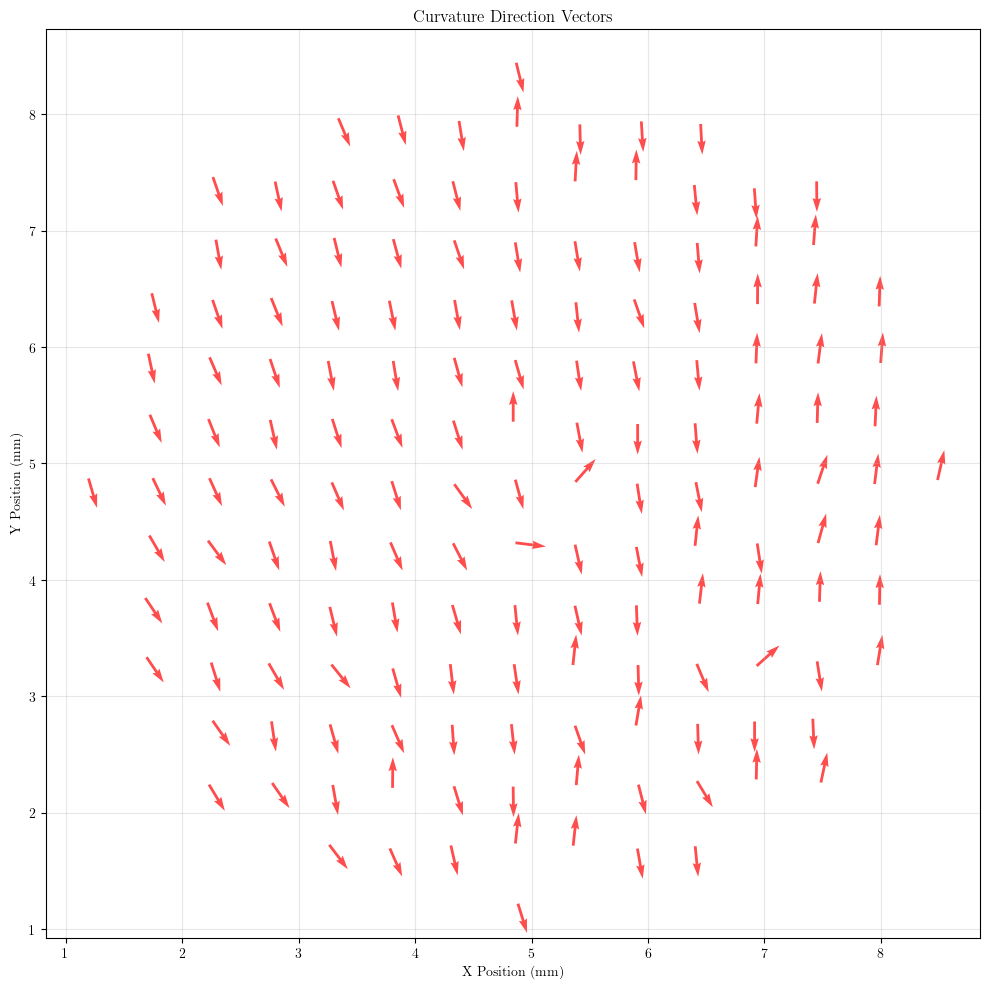

In [56]:

# Your existing setup
ro = 0.4 #mm
R = 7.78

x_positions = []
y_positions = []
u_components = []  # x-component of vectors
v_components = []  # y-component of vectors

mat_Angles = np.zeros((ncols, ncols))

for ii in range(1, ncols-1):
    for jj in range(1, ncols-1):
        x_looking = (mat_R_X[ii-1][jj] != 0 and mat_R_X[ii+1][jj] != 0 and 
                     mat_R_X[ii][jj+1] != 0 and mat_R_X[ii][jj-1] != 0)
        y_looking = (mat_R_Y[ii-1][jj] != 0 and mat_R_Y[ii+1][jj] != 0 and 
                     mat_R_Y[ii][jj+1] != 0 and mat_R_Y[ii][jj-1] != 0)
        
        if ((mat_R_X[ii][jj] != 0 and mat_R_Y[ii][jj] != 0) and x_looking and y_looking):
            center_x_coord = mat_R_X_hpref[ii][jj]
            
            # X-gradient deltas
            delta_x_a = mat_R_X[ii+1][jj] - mat_R_X_hpref[ii+1][jj]  # (y+1)
            delta_x_b = mat_R_X[ii][jj+1] - mat_R_X_hpref[ii][jj+1]  # (x+1)
            delta_x_c = mat_R_X[ii-1][jj] - mat_R_X_hpref[ii-1][jj]  # (y-1)
            delta_x_d = mat_R_X[ii][jj-1] - mat_R_X_hpref[ii][jj-1]  # (x-1)

            center_y_coord = mat_R_Y[ii][jj]
            
            # Y-gradient deltas
            delta_y_a = mat_R_Y[ii+1][jj] - mat_R_Y_hpref[ii+1][jj]  # (y+1)
            delta_y_b = mat_R_Y[ii][jj+1] - mat_R_Y_hpref[ii][jj+1]  # (x+1)
            delta_y_c = mat_R_Y[ii-1][jj] - mat_R_Y_hpref[ii-1][jj]  # (y-1) 
            delta_y_d = mat_R_Y[ii][jj-1] - mat_R_Y_hpref[ii][jj-1]  # (x-1)

            # --- *** START: CORRECTED ANGLE CALCULATION *** ---
            
            # 1. Calculate the second derivative terms
            S_xx_term = delta_x_b - delta_x_d 
            S_yy_term = delta_y_a - delta_y_c
            
            S_xy_term = delta_x_a - delta_x_c
            S_yx_term = delta_y_b - delta_y_d
            S_xy_avg_term = (S_xy_term + S_yx_term) / 2.0 

            # 2. Build the formula: tan(2*theta) = 2*S_xy / (S_xx - S_yy)
            numerator = 2.0 * S_xy_avg_term
            denominator = S_xx_term - S_yy_term

            # 3. Calculate angle using np.arctan2
            # This is the corrected line. It replaces the entire if/else block.
            # It correctly finds the angle 2*theta in the full -pi to +pi range,
            # so the final 'angle' is in the -pi/2 to +pi/2 range.
            angle = 0.5 * np.arctan2(numerator, denominator)
            
            # --- *** END: CORRECTED ANGLE CALCULATION *** ---
            
            mat_Angles[ii][jj] = angle
            
            # Store positions and vector components for plotting
            x_positions.append(center_x_coord)
            y_positions.append(center_y_coord)
            u_components.append(np.cos(angle))  # x-component of unit vector
            v_components.append(np.sin(angle))  # y-component of unit vector

# --- (Rest of your plotting code is correct) ---

# Convert to numpy arrays for plotting
x_positions = np.array(x_positions)
y_positions = np.array(y_positions)
u_components = np.array(u_components)
v_components = np.array(v_components)

# Create the vector plot
plt.figure(figsize=(10, 10))
plt.quiver(x_positions, y_positions, u_components, v_components, 
           angles='xy', scale_units='xy', scale=3.8, 
           color='red', alpha=0.7, width=0.003)

# Customize the plot
plt.xlabel('X Position (mm)')
plt.ylabel('Y Position (mm)')
plt.title('Curvature Direction Vectors')
plt.grid(True, alpha=0.3)
plt.axis('equal') 

plt.tight_layout()


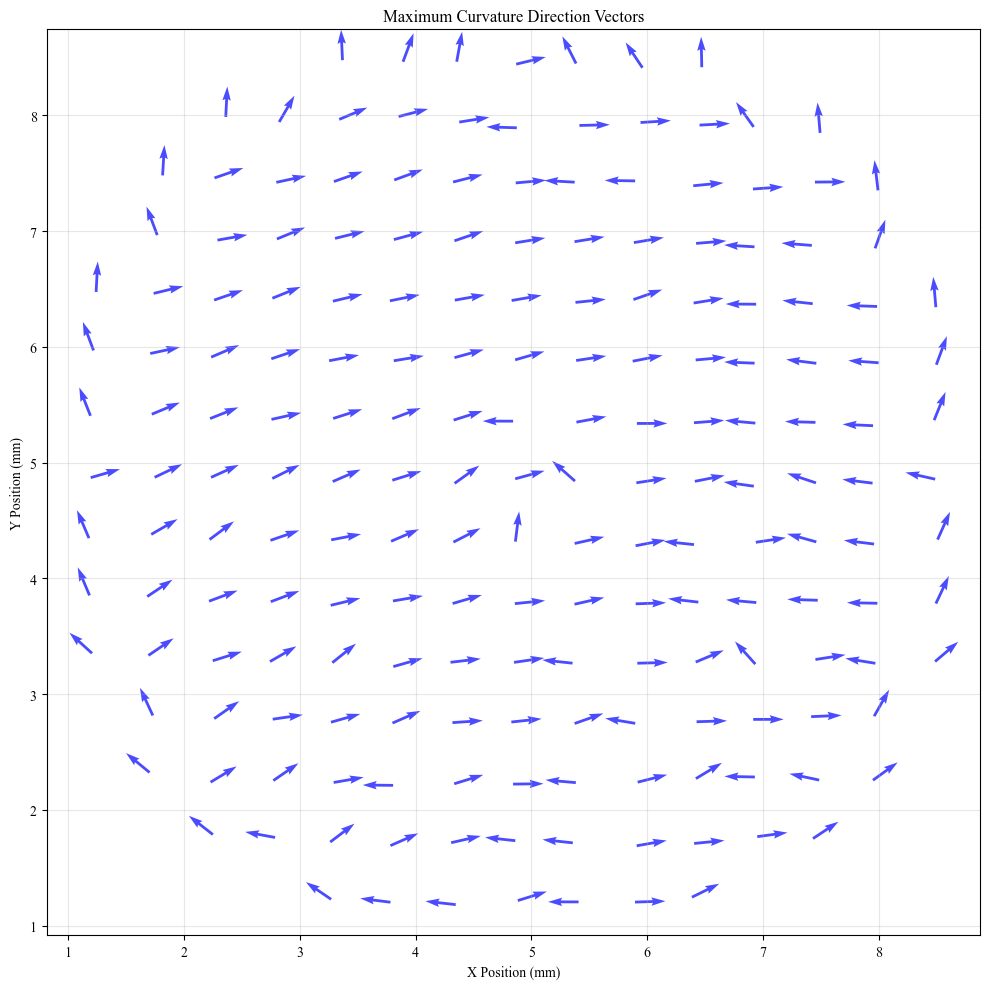

In [76]:
# Your existing setup
ro = 0.4 #mm
R = 7.78

x_positions = []
y_positions = []
u_components_max = [] # x-component of MAXIMUM curvature vectors
v_components_max = [] # y-component of MAXIMUM curvature vectors

# Assuming ncols is defined and contains the matrix dimension
mat_Angles = np.zeros((ncols, ncols))

for ii in range(1, ncols-1):
    for jj in range(1, ncols-1):
        # ... (Rest of your delta calculations are here and unchanged) ...
        # [Skipping delta calculations for brevity]

        if (mat_R_X[ii][jj] != 0 and mat_R_Y[ii][jj] != 0):
            center_x_coord = mat_R_X_hpref[ii][jj]
            # ... (delta_x, delta_y calculations) ...
            
            # X-gradient deltas (all 4 directions)
            delta_x_a = mat_R_X[ii+1][jj] - mat_R_X_hpref[ii+1][jj] # (y+1)
            delta_x_b = mat_R_X[ii][jj+1] - mat_R_X_hpref[ii][jj+1] # (x+1)
            delta_x_c = mat_R_X[ii-1][jj] - mat_R_X_hpref[ii-1][jj] # (y-1)
            delta_x_d = mat_R_X[ii][jj-1] - mat_R_X_hpref[ii][jj-1] # (x-1)

            center_y_coord = mat_R_Y[ii][jj]
            
            # Y-gradient deltas
            delta_y_a = mat_R_Y[ii+1][jj] - mat_R_Y_hpref[ii+1][jj] # (y+1)
            delta_y_b = mat_R_Y[ii][jj+1] - mat_R_Y_hpref[ii][jj+1] # (x+1)
            delta_y_c = mat_R_Y[ii-1][jj] - mat_R_Y_hpref[ii-1][jj] # (y-1) 
            delta_y_d = mat_R_Y[ii][jj-1] - mat_R_Y_hpref[ii][jj-1] # (x-1)


            # 1. Calculate the second derivative terms
            S_xx_term = delta_x_b - delta_x_d 
            S_yy_term = delta_y_a - delta_y_c
            S_xy_term = delta_x_a - delta_x_c
            S_yx_term = delta_y_b - delta_y_d
            S_xy_avg_term = (S_xy_term + S_yx_term) / 2.0 

            # 2. Build the formula (Numerator and Denominator)
            numerator = 2.0 * S_xy_avg_term
            denominator = S_xx_term - S_yy_term

            # 3. Calculate MINIMUM principal angle (original calculation)
            angle_min = 0.5 * np.arctan2(numerator, denominator)
            
            # --- *** NEW CODE FOR MAXIMUM CURVATURE *** ---
            # 4. Calculate MAXIMUM principal angle
            # The maximum angle is 90 degrees (pi/2) offset from the minimum angle.
            angle_max = angle_min + np.pi / 2.0
            
            # --- *** END NEW CODE *** ---
            
            mat_Angles[ii][jj] = angle_max # Store the max angle
            
            # Store positions and vector components for plotting
            x_positions.append(center_x_coord)
            y_positions.append(center_y_coord)
            
            # Use the MAXIMUM angle for components
            u_components_max.append(np.cos(angle_max)) 
            v_components_max.append(np.sin(angle_max)) 

# Convert to numpy arrays for plotting
x_positions = np.array(x_positions)
y_positions = np.array(y_positions)
u_components_max = np.array(u_components_max)
v_components_max = np.array(v_components_max)

# Create the vector plot (plotting the maximum curvature directions)
plt.figure(figsize=(10, 10))
plt.quiver(x_positions, y_positions, u_components_max, v_components_max, 
           angles='xy', scale_units='xy', scale=3.8, 
           color='blue', alpha=0.7, width=0.003)

# Customize the plot
plt.xlabel('X Position (mm)')
plt.ylabel('Y Position (mm)')
plt.title('Maximum Curvature Direction Vectors')
plt.grid(True, alpha=0.3)
plt.axis('equal') 

plt.tight_layout()

<h1><center><b>Focus error (S)</b><center></h1>

In [57]:
mat_S = np.zeros((ncols,ncols))

In [58]:
ro = 0.4 #We passed from milimeters to meters
R = 7.78 #We passed from milimeters to meters
for ii in range(1,ncols-1): #This limits were stablished in order to avoid violating the range in which the matrix is defined
    for jj in range(1,ncols-1):
        x_looking = mat_R_X[ii-1][jj] != 0 and mat_R_X[ii+1][jj]!=0 and mat_R_X[ii][jj+1]!=0 and mat_R_X[ii][jj-1]!=0
        y_looking = mat_R_Y[ii-1][jj] != 0 and mat_R_Y[ii+1][jj]!=0 and mat_R_Y[ii][jj+1]!=0 and mat_R_Y[ii][jj-1]!=0
        if ((mat_R_X[ii][jj]!=0 and mat_R_Y[ii][jj]!= 0) and x_looking and y_looking):
            center_x_coord = mat_R_X_hpref[ii][jj]
            delta_x_a = mat_R_X[ii][jj+1] - mat_R_X_hpref[ii][jj+1]
            delta_x_b = mat_R_X[ii+1][jj] - mat_R_X_hpref[ii+1][jj]
            delta_x_c = mat_R_X[ii][jj-1] - mat_R_X_hpref[ii][jj-1]
            delta_x_d = mat_R_X[ii-1][jj] - mat_R_X_hpref[ii-1][jj]

            center_y_coord = mat_R_Y[ii][jj]
            delta_y_a = mat_R_Y[ii][jj+1] - mat_R_Y_hpref[ii][jj+1]
            delta_y_b = mat_R_Y[ii-1][jj] - mat_R_Y_hpref[ii-1][jj]
            delta_y_d = mat_R_Y[ii+1][jj] - mat_R_Y_hpref[ii+1][jj]

            
            S = (1/(4*ro*R))*(delta_x_a - delta_x_c + delta_y_b - delta_y_d + mat_C[ii][jj])


            mat_S[ii][jj] = S*1e-3

(-0.5, 16.5, 16.5, -0.5)

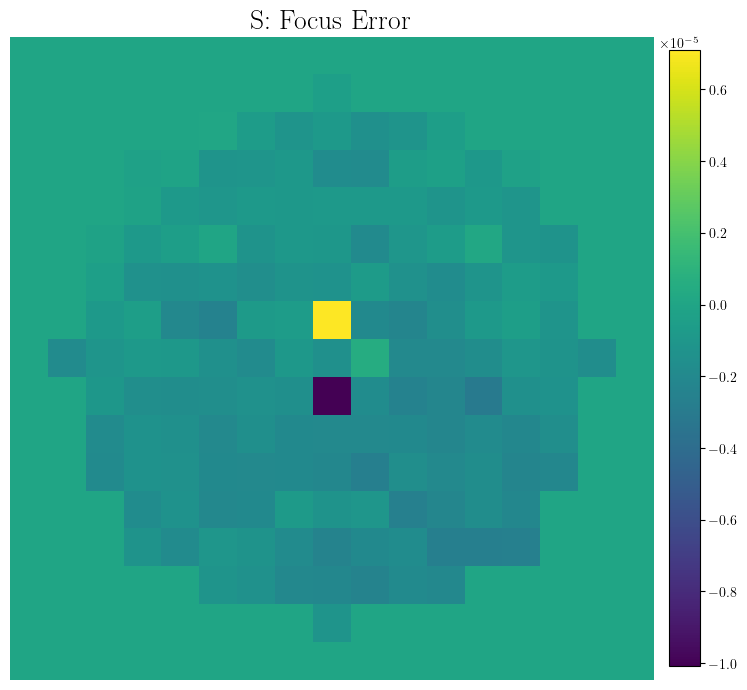

In [59]:
plt.figure(figsize=(10, 10))
im = plt.imshow(mat_S) 
cbar = plt.colorbar(im, shrink=0.8, pad=0.02) 
plt.title("S: Focus Error", fontsize=20)
plt.axis('off')

In [60]:
mat_C_max = np.zeros((ncols,ncols))
mat_C_min = np.zeros((ncols,ncols))

In [61]:
# R = 7-78 #We passed from milimeters to meters
# for ii in range(1,18): #This limits were stablished in order to avoid violating the range in which the matrix is defined
#     for jj in range(1,18):
#         x_looking = mat_R_X[ii-1][jj] != 0 and mat_R_X[ii+1][jj]!=0 and mat_R_X[ii][jj+1]!=0 and mat_R_X[ii][jj-1]!=0
#         y_looking = mat_R_Y[ii-1][jj] != 0 and mat_R_Y[ii+1][jj]!=0 and mat_R_Y[ii][jj+1]!=0 and mat_R_Y[ii][jj-1]!=0
#         if ((mat_R_X[ii][jj]!=0 and mat_R_Y[ii][jj]!= 0) and x_looking and y_looking):

#             c_max = (1/R)*1.0 + mat_S[ii][jj] + mat_C[ii][jj]
#             c_min = (1/R)*1.0 + mat_S[ii][jj]
            
#             mat_C_min[ii][jj] = c_min
#             mat_C_max[ii][jj] = c_max

R = 7.78  # Fixed the R value

for ii in range(1, ncols-1):
    for jj in range(1, ncols-1):
        x_looking = (mat_R_X[ii-1][jj] != 0 and mat_R_X[ii+1][jj] != 0 and 
                    mat_R_X[ii][jj+1] != 0 and mat_R_X[ii][jj-1] != 0)
        y_looking = (mat_R_Y[ii-1][jj] != 0 and mat_R_Y[ii+1][jj] != 0 and 
                    mat_R_Y[ii][jj+1] != 0 and mat_R_Y[ii][jj-1] != 0)
        
        if ((mat_R_X[ii][jj] != 0 and mat_R_Y[ii][jj] != 0) and x_looking and y_looking):
            # First, compute the tensor components δ_xx, δ_yy, δ_xy, etc.
            delta_x_a = mat_R_X[ii][jj+1] - mat_R_X_hpref[ii][jj+1]
            delta_x_b = mat_R_X[ii+1][jj] - mat_R_X_hpref[ii+1][jj]
            delta_x_c = mat_R_X[ii][jj-1] - mat_R_X_hpref[ii][jj-1]
            delta_x_d = mat_R_X[ii-1][jj] - mat_R_X_hpref[ii-1][jj]

            center_y_coord = mat_R_Y[ii][jj]
            delta_y_a = mat_R_Y[ii][jj+1] - mat_R_Y_hpref[ii][jj+1]
            delta_y_b = mat_R_Y[ii-1][jj] - mat_R_Y_hpref[ii-1][jj]
            delta_y_c = mat_R_Y[ii][jj-1] - mat_R_Y_hpref[ii][jj-1]
            delta_y_d = mat_R_Y[ii+1][jj] - mat_R_Y_hpref[ii+1][jj]

            # Compute the tensor components
            δ_xx = (delta_x_a - delta_x_c) / (2 * ro * R)
            δ_yy = (delta_y_b - delta_y_d) / (2 * ro * R)
            δ_xy = (delta_x_b - delta_x_d + delta_y_a - delta_y_c) / (4 * ro * R)
            
            # Compute C (magnitude)
            C = ((δ_xx - δ_yy)**2 + (2 * δ_xy)**2)**0.5
            
            # Compute S (spherical component)
            S = -1/2 * (δ_xx + δ_yy + C)
            
            # Now compute maximum and minimum curvatures
            c_max = (1/R) + S + C
            c_min = (1/R) + S
            
            mat_C_min[ii][jj] = c_min
            mat_C_max[ii][jj] = c_max

C:\Users\PC\AppData\Local\Temp\ipykernel_6032\2116688422.py:2: RuntimeWarning: divide by zero encountered in divide
  im = plt.imshow(1/mat_C_max)


(-0.5, 16.5, 16.5, -0.5)

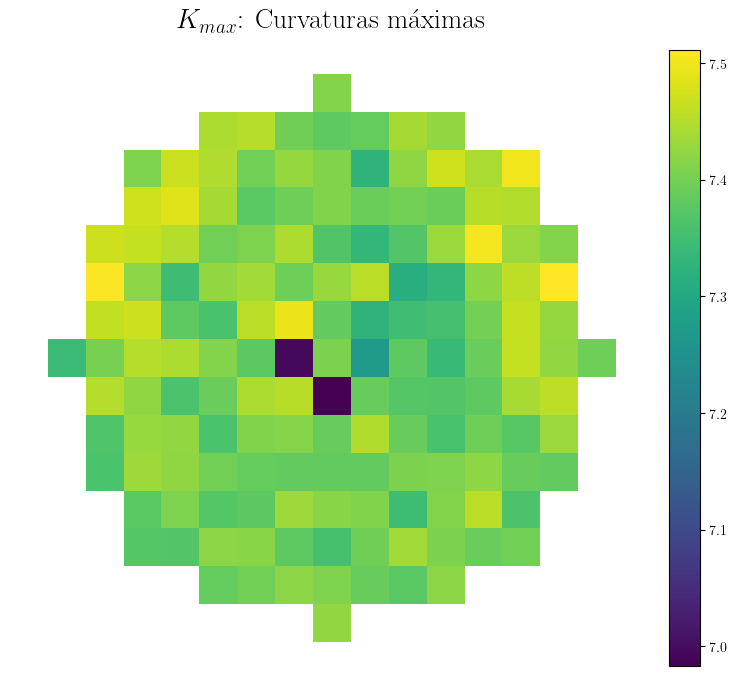

In [62]:
plt.figure(figsize=(10, 10))
im = plt.imshow(1/mat_C_max) 
cbar = plt.colorbar(im, shrink=0.8, pad=0.02) 
plt.title(r"$K_{max}$: Curvaturas máximas", fontsize=20)
plt.axis('off')

C:\Users\PC\AppData\Local\Temp\ipykernel_6032\344796321.py:2: RuntimeWarning: divide by zero encountered in divide
  im = plt.imshow(1/mat_C_min)


(-0.5, 16.5, 16.5, -0.5)

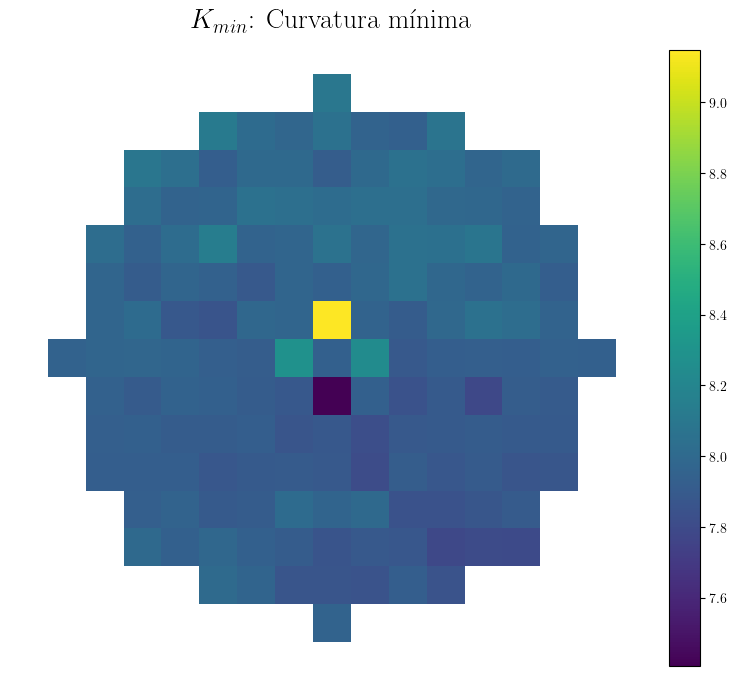

In [63]:
plt.figure(figsize=(10, 10))
im = plt.imshow(1/mat_C_min) 
cbar = plt.colorbar(im, shrink=0.8, pad=0.02) 
plt.title(r"$K_{min}$: Curvatura mínima", fontsize=20)
plt.axis('off')

In [64]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Disable LaTeX to avoid errors
plt.rcParams['text.usetex'] = False

def compute_elevation_discrete(mat_R_X, mat_R_Y, mat_R_X_hpref, mat_R_Y_hpref, R, ρ=0.4):
    """
    Compute elevation for each discrete point in the 19x19 grid
    """
    N = 17
    Δh = np.zeros((N, N))
    
    # Convert to numpy arrays
    R_X = np.array(mat_R_X)
    R_Y = np.array(mat_R_Y)
    R_X_hpref = np.array(mat_R_X_hpref)
    R_Y_hpref = np.array(mat_R_Y_hpref)
    
    # Calculate displacements
    delta_x_mat = R_X - R_X_hpref
    delta_y_mat = R_Y - R_Y_hpref
    
    # Simple integration from center outward
    center_i, center_j = N//2, N//2
    Δh[center_i, center_j] = 0
    
    # For each point, compute elevation relative to neighbors
    for i in range(N):
        for j in range(N):
            if (i, j) == (center_i, center_j):
                continue
                
            # Use available neighbors for integration
            valid_neighbors = []
            
            # Check left neighbor
            if j > 0 and delta_x_mat[i, j-1] != 0 and delta_x_mat[i, j] != 0:
                Δh_left = Δh[i, j-1] + (1/R) * (
                    4 * (delta_x_mat[i, j-1] + delta_x_mat[i, j]) * ρ +
                    (1/3) * (delta_y_mat[i, j-1] + delta_y_mat[i, j]) * ρ
                )
                valid_neighbors.append(Δh_left)
            
            # Check right neighbor  
            if j < N-1 and delta_x_mat[i, j+1] != 0 and delta_x_mat[i, j] != 0:
                Δh_right = Δh[i, j+1] + (1/R) * (
                    4 * (delta_x_mat[i, j+1] + delta_x_mat[i, j]) * ρ +
                    (1/3) * (delta_y_mat[i, j+1] + delta_y_mat[i, j]) * ρ
                )
                valid_neighbors.append(Δh_right)
            
            # Check bottom neighbor
            if i > 0 and delta_x_mat[i-1, j] != 0 and delta_x_mat[i, j] != 0:
                Δh_bottom = Δh[i-1, j] + (1/R) * (
                    4 * (delta_x_mat[i-1, j] + delta_x_mat[i, j]) * ρ +
                    (1/3) * (delta_y_mat[i-1, j] + delta_y_mat[i, j]) * ρ
                )
                valid_neighbors.append(Δh_bottom)
            
            # Check top neighbor
            if i < N-1 and delta_x_mat[i+1, j] != 0 and delta_x_mat[i, j] != 0:
                Δh_top = Δh[i+1, j] + (1/R) * (
                    4 * (delta_x_mat[i+1, j] + delta_x_mat[i, j]) * ρ +
                    (1/3) * (delta_y_mat[i+1, j] + delta_y_mat[i, j]) * ρ
                )
                valid_neighbors.append(Δh_top)
            
            # Use average of available neighbors
            if valid_neighbors:
                Δh[i, j] = np.mean(valid_neighbors)
    
    return Δh

# Compute elevation
ρ = 0.4
R = 7.78
Δh = compute_elevation_discrete(mat_R_X, mat_R_Y, mat_R_X_hpref, mat_R_Y_hpref, R, ρ)

# Get the coordinates for each point
X_points = np.array(mat_R_X_hpref)
Y_points = np.array(mat_R_Y_hpref)

# Create 3D scatter plot of discrete points
# fig = plt.figure(figsize=(12, 10))

# # 3D Scatter plot
# ax1 = fig.add_subplot(221, projection='3d')
# scatter1 = ax1.scatter(X_points, Y_points, Δh, c=Δh, cmap='viridis', s=50)
# ax1.set_title('3D Discrete Points - Elevation Map')
# ax1.set_xlabel('X Position (mm)')
# ax1.set_ylabel('Y Position (mm)')
# ax1.set_zlabel('Elevation Δh (mm)')
# plt.colorbar(scatter1, ax=ax1, shrink=0.5, aspect=20, label='Δh (mm)')

# # Add grid lines to show the tiles
# for i in range(19):
#     for j in range(19):
#         if Δh[i, j] != 0:  # Only plot if we have data
#             ax1.plot([X_points[i, j]], [Y_points[i, j]], [Δh[i, j]], 
#                     'o', markersize=5, color=plt.cm.viridis((Δh[i, j] - Δh.min()) / (Δh.max() - Δh.min())))

# # 2D Scatter plot (top view)
# ax2 = fig.add_subplot(222)
# scatter2 = ax2.scatter(X_points, Y_points, c=Δh, cmap='viridis', s=100)
# ax2.set_title('2D Top View - Elevation Map')
# ax2.set_xlabel('X Position (mm)')
# ax2.set_ylabel('Y Position (mm)')
# plt.colorbar(scatter2, ax=ax2, label='Δh (mm)')

# # Add grid lines in 2D
# ax2.grid(True, alpha=0.3)
# for i in range(19):
#     for j in range(19):
#         if Δh[i, j] != 0:
#             ax2.text(X_points[i, j], Y_points[i, j], f'{Δh[i, j]:.3f}', 
#                     fontsize=6, ha='center', va='center')

# # Wireframe with points
# ax3 = fig.add_subplot(223, projection='3d')
# # Plot the grid
# for i in range(19):
#     for j in range(19):
#         if Δh[i, j] != 0:
#             ax3.scatter(X_points[i, j], Y_points[i, j], Δh[i, j], 
#                        c=Δh[i, j], cmap='viridis', s=80)
            
# # Connect points with lines to show the grid structure
# for i in range(19):
#     for j in range(18):
#         if Δh[i, j] != 0 and Δh[i, j+1] != 0:
#             ax3.plot([X_points[i, j], X_points[i, j+1]], 
#                     [Y_points[i, j], Y_points[i, j+1]], 
#                     [Δh[i, j], Δh[i, j+1]], 'gray', alpha=0.3)

# for i in range(18):
#     for j in range(19):
#         if Δh[i, j] != 0 and Δh[i+1, j] != 0:
#             ax3.plot([X_points[i, j], X_points[i+1, j]], 
#                     [Y_points[i, j], Y_points[i+1, j]], 
#                     [Δh[i, j], Δh[i+1, j]], 'gray', alpha=0.3)

# ax3.set_title('3D Grid with Connections')
# ax3.set_xlabel('X Position (mm)')
# ax3.set_ylabel('Y Position (mm)')
# ax3.set_zlabel('Elevation Δh (mm)')

# # Simple bar chart style
# ax4 = fig.add_subplot(224, projection='3d')
# for i in range(19):
#     for j in range(19):
#         if Δh[i, j] != 0:
#             ax4.bar3d(X_points[i, j], Y_points[i, j], 0, 
#                      0.3, 0.3, Δh[i, j], 
#                      color=plt.cm.viridis((Δh[i, j] - Δh.min()) / (Δh.max() - Δh.min())),
#                      alpha=0.7)

# ax4.set_title('3D Bars - Elevation Height')
# ax4.set_xlabel('X Position (mm)')
# ax4.set_ylabel('Y Position (mm)')
# ax4.set_zlabel('Elevation Δh (mm)')

# plt.tight_layout()
# plt.show()

# # Print the elevation matrix
# print("Elevation Matrix (19×19):")
# print("Rows: 0-18, Columns: 0-18")
# print("Format: Δh[i,j] in mm")
# print("\nMatrix values:")
# for i in range(19):
#     row = []
#     for j in range(19):
#         if Δh[i, j] == 0:
#             row.append("  0.000  ")
#         else:
#             row.append(f"{Δh[i, j]:8.6f}")
#     print(f"Row {i:2}: {row}")

# print(f"\nStatistics:")
# print(f"Non-zero points: {np.count_nonzero(Δh)} out of {19*19}")
# print(f"Max elevation: {np.max(Δh):.6f} mm at position {np.unravel_index(np.argmax(Δh), Δh.shape)}")
# print(f"Min elevation: {np.min(Δh):.6f} mm at position {np.unravel_index(np.argmin(Δh), Δh.shape)}")

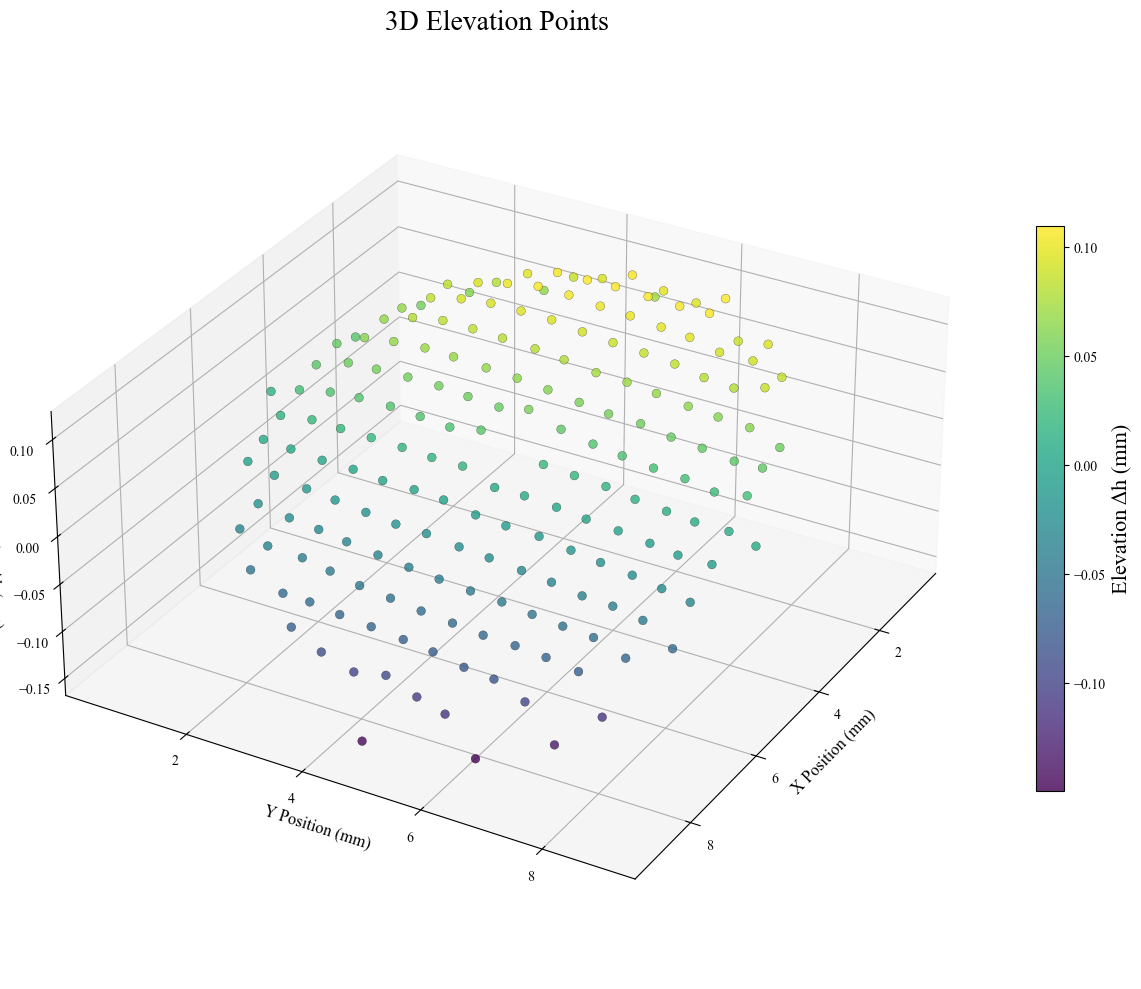

In [65]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Create the plot
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# Collect all valid points
x_vals = []
y_vals = []
z_vals = []

for i in range(ncols):
    for j in range(ncols):
        if Δh[i, j] != 0:
            x_vals.append(X_points[i, j])
            y_vals.append(Y_points[i, j])
            z_vals.append(Δh[i, j])

# Plot points
scatter = ax.scatter(x_vals, y_vals, z_vals, 
                    c=z_vals, cmap='viridis', s=40, 
                    alpha=0.8, edgecolors='black', linewidth=0.2)

# Customize the view
ax.set_title('3D Elevation Points', fontsize=20)
ax.set_xlabel('X Position (mm)', fontsize=12)
ax.set_ylabel('Y Position (mm)', fontsize=12)
ax.set_zlabel('Elevation Δh (mm)', fontsize=12)

# Add grid for better spatial reference
ax.grid(True, alpha=0.3)

ax.view_init(elev=30, azim=30)

# Colorbar
cbar = plt.colorbar(scatter, ax=ax, shrink=0.6, aspect=20)
cbar.set_label('Elevation Δh (mm)', fontsize=16)

# Set equal aspect ratio for better visualization
ax.set_box_aspect([1, 1, 0.5])  # Adjust the z-axis scaling

plt.tight_layout()
plt.show()

C:\Users\PC\AppData\Local\Temp\ipykernel_6032\3807175794.py:42: RuntimeWarning: divide by zero encountered in divide
  im4 = ax4.imshow(1 / mat_C_max)
C:\Users\PC\AppData\Local\Temp\ipykernel_6032\3807175794.py:49: RuntimeWarning: divide by zero encountered in divide
  im5 = ax5.imshow(1 / mat_C_min)


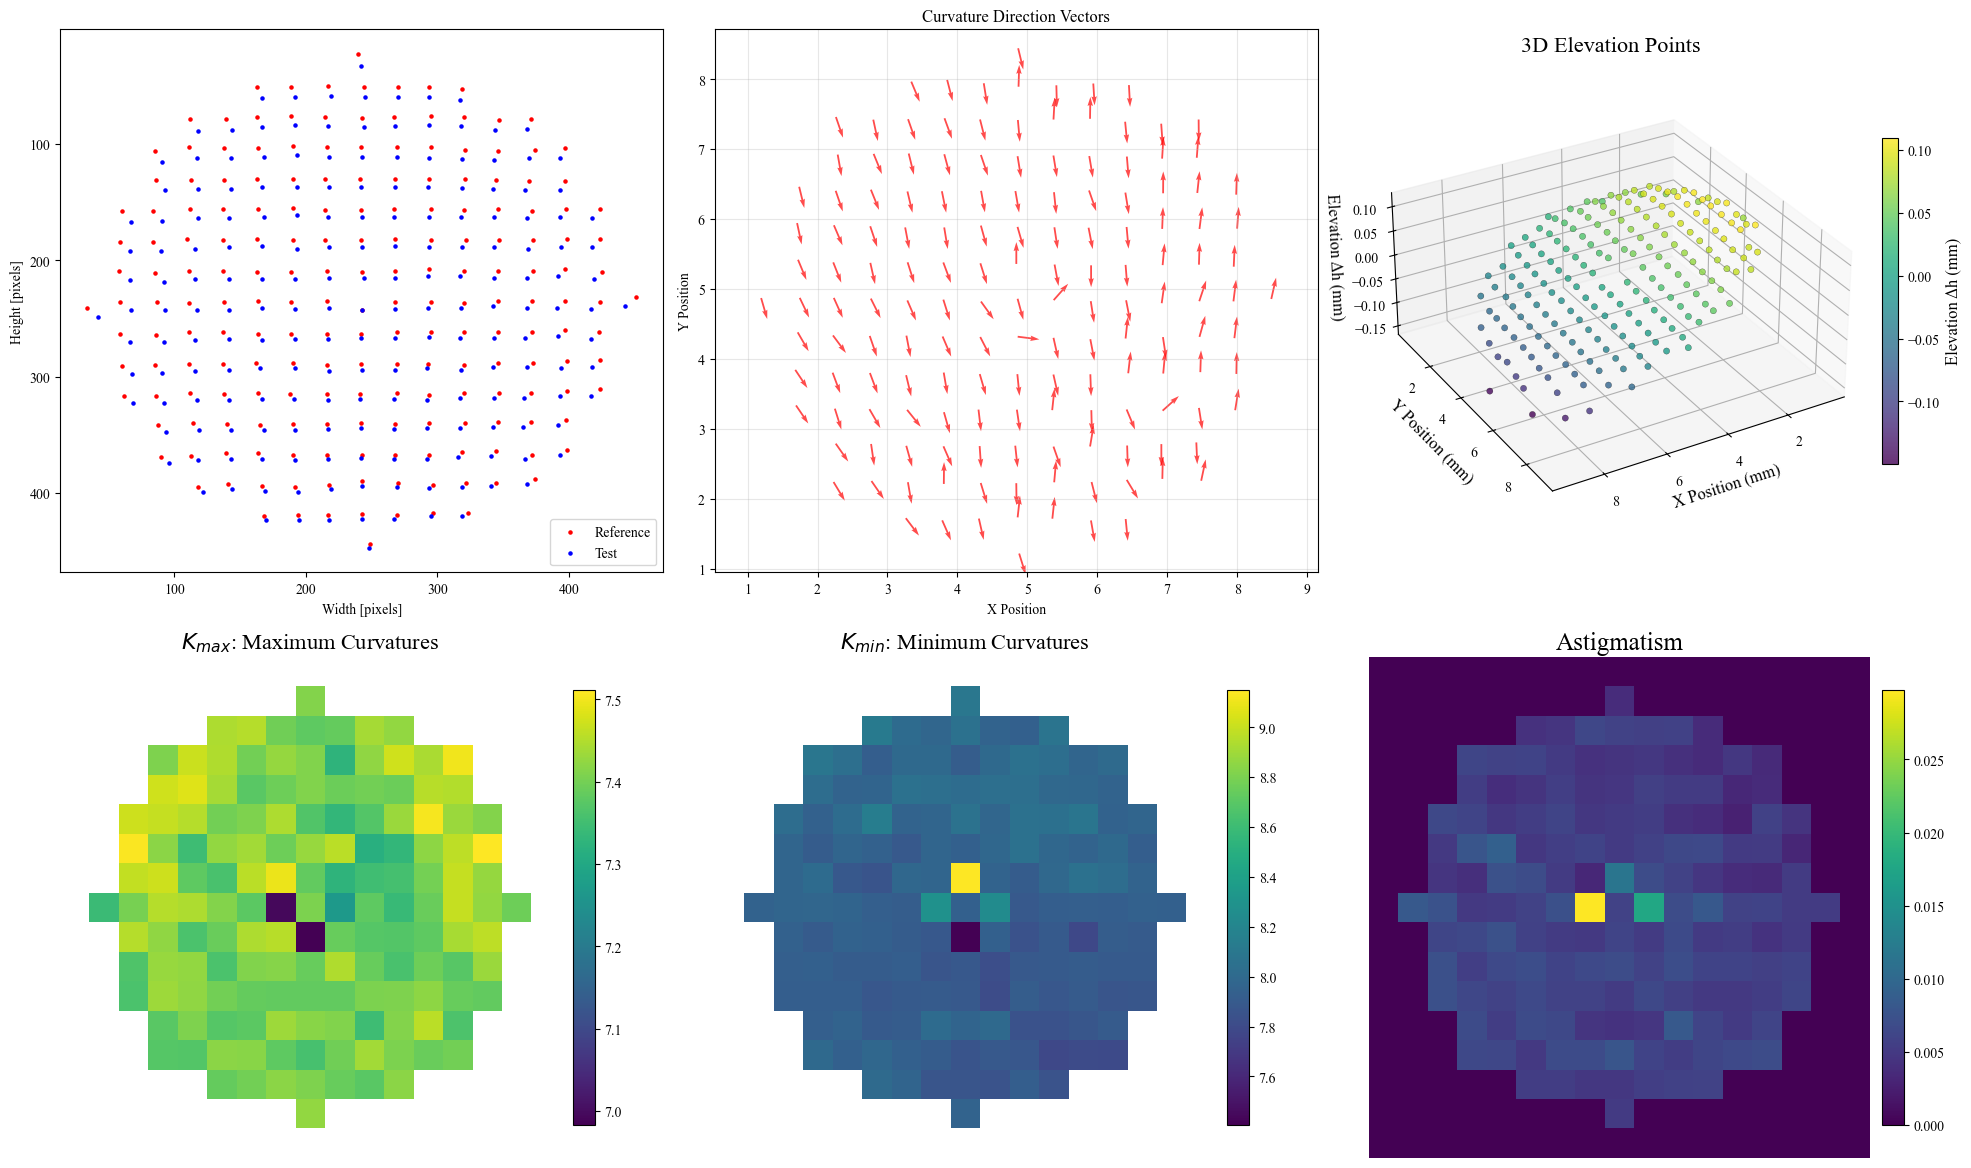

In [66]:
fig = plt.figure(figsize=(20, 12))

# === (1,1) Scatter Comparison ===
ax1 = fig.add_subplot(2, 3, 1)
ax1.scatter(y1, x1, c="red", s=5, label="Reference")
ax1.scatter(x2, y2, c="blue", s=5, label="Test")
ax1.set_xlabel('Width [pixels]')
ax1.set_ylabel('Height [pixels]')
ax1.legend(fontsize=10, loc="lower right")
ax1.invert_yaxis()

# === (1,2) Quiver (Vector Field) ===
ax2 = fig.add_subplot(2, 3, 2)
ax2.quiver(x_positions, y_positions, u_components, v_components,
           angles='xy', scale_units='xy', scale=3.2,
           color='red', alpha=0.7, width=0.003)
ax2.set_xlabel('X Position')
ax2.set_ylabel('Y Position')
ax2.set_title('Curvature Direction Vectors')
ax2.grid(True, alpha=0.3)
ax2.axis('equal')

# === (1,3) 3D Scatter ===
ax3 = fig.add_subplot(2, 3, 3, projection='3d')
scatter = ax3.scatter(x_vals, y_vals, z_vals,
                      c=z_vals, cmap='viridis', s=20,
                      alpha=0.8, edgecolors='black', linewidth=0.2)
ax3.set_title('3D Elevation Points', fontsize=16)
ax3.set_xlabel('X Position (mm)', fontsize=12)
ax3.set_ylabel('Y Position (mm)', fontsize=12)
ax3.set_zlabel('Elevation Δh (mm)', fontsize=12)
ax3.grid(True, alpha=0.3)
ax3.view_init(elev=30, azim=60)
ax3.set_box_aspect([1, 1, 0.5])

# Colorbar for 3D scatter
cbar3 = fig.colorbar(scatter, ax=ax3, shrink=0.6, aspect=20)
cbar3.set_label('Elevation Δh (mm)', fontsize=12)

# === (2,1) Kmax ===
ax4 = fig.add_subplot(2, 3, 4)
im4 = ax4.imshow(1 / mat_C_max)
cbar4 = fig.colorbar(im4, ax=ax4, shrink=0.8, pad=0.02)
ax4.set_title(r"$K_{max}$: Maximum Curvatures", fontsize=16)
ax4.axis('off')

# === (2,2) Kmin ===
ax5 = fig.add_subplot(2, 3, 5)
im5 = ax5.imshow(1 / mat_C_min)
cbar5 = fig.colorbar(im5, ax=ax5, shrink=0.8, pad=0.02)
ax5.set_title(r"$K_{min}$: Minimum Curvatures", fontsize=16)
ax5.axis('off')

# === (2,3) Astigmatism ===
ax6 = fig.add_subplot(2, 3, 6)
im6 = ax6.imshow(mat_C, cmap="viridis")
cbar6 = fig.colorbar(im6, ax=ax6, shrink=0.8, pad=0.02)
ax6.set_title("Astigmatism", fontsize=18)
ax6.axis('off')

# Adjust layout
plt.tight_layout()
plt.show()

<h1><center><b> Campbell

In [67]:
nr, nc = 17,17
p = 0.4 #mm
SbarX = np.zeros((nr,nc))
SbarY = np.zeros((nr,nc))
valid = np.zeros((17, 17))
Cx = np.zeros((nr,nc))

In [68]:
for ii in range(1,ncols-1): #This limits were stablished in order to avoid violating the range in which the matrix is defined
    for jj in range(1,ncols-1):
        x_looking = mat_R_X[ii][jj] != 0 and mat_R_X[ii+1][jj]!=0 and mat_R_X[ii][jj+1]!=0 and mat_R_X[ii+1][jj+1]!=0
        y_looking = mat_R_Y[ii][jj] != 0 and mat_R_Y[ii+1][jj]!=0 and mat_R_Y[ii][jj+1]!=0 and mat_R_Y[ii+1][jj+1]!=0
        if ((mat_R_X[ii][jj]!=0 and mat_R_Y[ii][jj]!= 0) and x_looking and y_looking):

            valid[ii][jj] = 1

            center_x_coord = mat_R_X_hpref[ii][jj]
            delta_x_a = mat_R_X[ii][jj+1] - mat_R_X_hpref[ii][jj+1]
            delta_x_b = mat_R_X[ii+1][jj] - mat_R_X_hpref[ii+1][jj]
            delta_x_c = mat_R_X[ii][jj-1] - mat_R_X_hpref[ii][jj-1]
            delta_x_d = mat_R_X[ii-1][jj] - mat_R_X_hpref[ii-1][jj]

            center_y_coord = mat_R_Y[ii][jj]
            delta_y_a = mat_R_Y[ii][jj+1] - mat_R_Y_hpref[ii][jj+1]
            delta_y_b = mat_R_Y[ii-1][jj] - mat_R_Y_hpref[ii-1][jj]
            delta_y_c = mat_R_Y[ii][jj-1] - mat_R_Y_hpref[ii][jj-1]
            delta_y_d = mat_R_Y[ii+1][jj] - mat_R_Y_hpref[ii+1][jj]

            SbarX[ii][jj] = 0.25 * (delta_x_a + delta_x_b + delta_x_c + delta_x_d)
            SbarY[ii][jj] = 0.25 * (delta_y_a + delta_y_b + delta_y_c + delta_y_d)

            Cx[ii][jj] = (1/4*p)*((-delta_x_a - delta_x_b + delta_x_d + delta_x_c ) + ( -1*delta_y_a + delta_y_b + delta_y_d - delta_y_c))
            

In [69]:
Z = np.zeros((nr,nc))
f = np.zeros((nr,nc)) #This track the number of points that each point is computed

#Center
nrc = round(nr/2)
ncc = round(nr/2)

f[nrc,ncc] = 1 #Center point is filled

# Right upper cuadrant

for r in range(nrc, nr - 1):
    for c in range(ncc, nc - 1):
        if valid[r, c] == 1:
            z_ref = Z[r, c]
            s_x = SbarX[r, c]
            s_y = SbarY[r, c]
            c_x_term = (p**2 * Cx[r, c]) / 2.0

            # Calculate elevations for the other 3 corners. Eq ( 19-21 )
            z_new_1 = z_ref + (p * s_x) - c_x_term         # Z(r, c+1)
            z_new_2 = z_ref + (p * s_y) - c_x_term         # Z(r+1, c)
            z_new_3 = z_ref + p * (s_x + s_y)             # Z(r+1, c+1)

            # Update surface Z with running average (Eq. 22) [cite: 282]
            Z[r, c+1] = (f[r, c+1] * Z[r, c+1] + z_new_1) / (f[r, c+1] + 1.0)
            Z[r+1, c] = (f[r+1, c] * Z[r+1, c] + z_new_2) / (f[r+1, c] + 1.0)
            Z[r+1,c+1] = (f[r+1,c+1] * Z[r+1,c+1] + z_new_3) / (f[r+1,c+1] + 1.0)

            # Increment counters
            f[r, c+1] += 1
            f[r+1, c] += 1
            f[r+1, c+1] += 1

# Left upper quadrant

for r in range(nrc, nr - 1):
    for c in range(ncc, 0, -1): # Iterate c from ncc down to 1
        if valid[r, c-1] == 1:
            z_ref = Z[r, c] # Reference corner is (r, c)
            s_x = SbarX[r, c-1]
            s_y = SbarY[r, c-1]
            c_x_term = (p**2 * Cx[r, c-1]) / 2.0

            # Calculate elevations
            z_new_1 = z_ref - (p * s_x) + c_x_term         # Z(r, c-1)
            z_new_2 = z_ref + (p * s_y) + c_x_term         # Z(r+1, c)
            z_new_3 = z_ref - p * (s_x - s_y)             # Z(r+1, c-1)

            # Update surface Z with running average
            Z[r, c-1]   = (f[r, c-1] * Z[r, c-1] + z_new_1) / (f[r, c-1] + 1.0)
            Z[r+1, c]   = (f[r+1, c] * Z[r+1, c] + z_new_2) / (f[r+1, c] + 1.0)
            Z[r+1, c-1] = (f[r+1,c-1] * Z[r+1,c-1] + z_new_3) / (f[r+1,c-1] + 1.0)

            # Increment counters
            f[r, c-1] += 1
            f[r+1, c] += 1
            f[r+1, c-1] += 1

# Left lower quadrant
for r in range(nrc, 0, -1): # Iterate r from nrc down to 1
    for c in range(ncc, 0, -1): # Iterate c from ncc down to 1
        if valid[r-1, c-1] == 1:
            z_ref = Z[r, c] # Reference corner is (r, c)
            s_x = SbarX[r-1, c-1]
            s_y = SbarY[r-1, c-1]
            c_x_term = (p**2 * Cx[r-1, c-1]) / 2.0

            # Calculate elevations
            z_new_1 = z_ref - (p * s_x) - c_x_term         # Z(r, c-1)
            z_new_2 = z_ref - (p * s_y) - c_x_term         # Z(r-1, c)
            z_new_3 = z_ref - p * (s_x + s_y)             # Z(r-1, c-1)

            # Update surface Z with running average
            Z[r, c-1]   = (f[r, c-1] * Z[r, c-1] + z_new_1) / (f[r, c-1] + 1.0)
            Z[r-1, c]   = (f[r-1, c] * Z[r-1, c] + z_new_2) / (f[r-1, c] + 1.0)
            Z[r-1, c-1] = (f[r-1,c-1] * Z[r-1,c-1] + z_new_3) / (f[r-1,c-1] + 1.0)

            # Increment counters
            f[r, c-1] += 1
            f[r-1, c] += 1
            f[r-1, c-1] += 1

# Right lower quadrant
for r in range(nrc, 0, -1): # Iterate r from nrc down to 1
    for c in range(ncc, nc - 1): # Iterate c from ncc to 17
        if valid[r-1, c] == 1:
            z_ref = Z[r, c] # Reference corner is (r, c)
            s_x = SbarX[r-1, c]
            s_y = SbarY[r-1, c]
            c_x_term = (p**2 * Cx[r-1, c]) / 2.0

            # Calculate elevations
            z_new_1 = z_ref + (p * s_x) + c_x_term         # Z(r, c+1)
            z_new_2 = z_ref - (p * s_y) + c_x_term         # Z(r-1, c)
            z_new_3 = z_ref + p * (s_x - s_y)             # Z(r-1, c+1)

            # Update surface Z with running average
            Z[r, c+1]   = (f[r, c+1] * Z[r, c+1] + z_new_1) / (f[r, c+1] + 1.0)
            Z[r-1, c]   = (f[r-1, c] * Z[r-1, c] + z_new_2) / (f[r-1, c] + 1.0)
            Z[r-1, c+1] = (f[r-1,c+1] * Z[r-1,c+1] + z_new_3) / (f[r-1,c+1] + 1.0)
            
            # Increment counters
            f[r, c+1] += 1
            f[r-1, c] += 1
            f[r-1, c+1] += 1


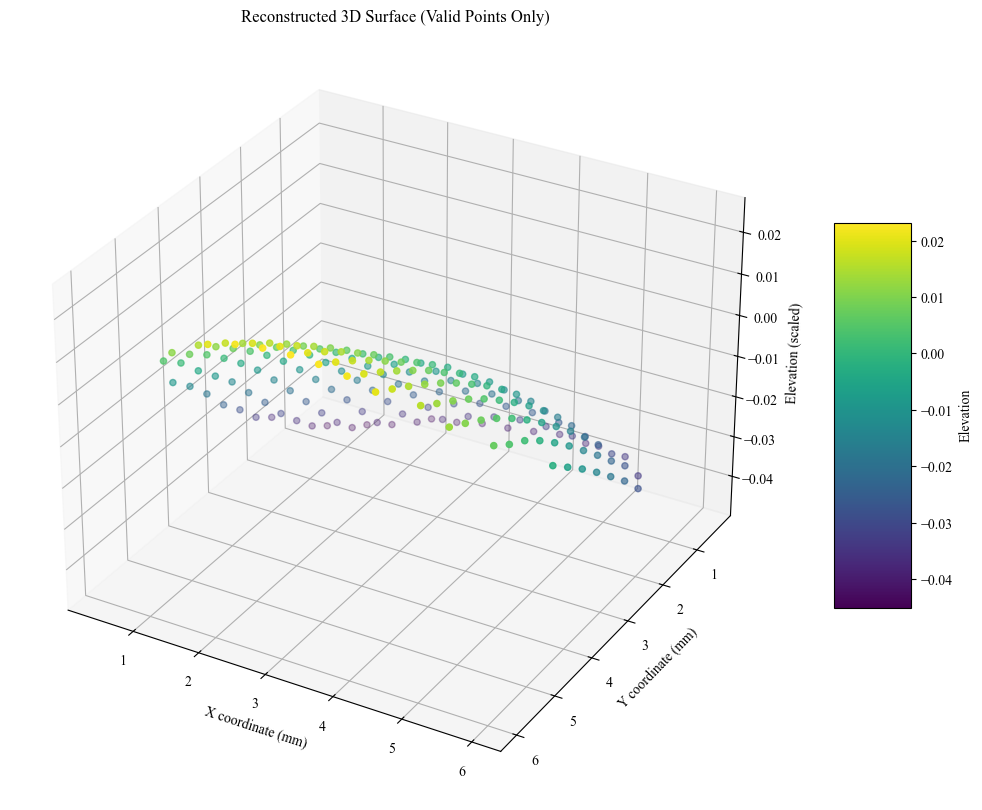

In [70]:
x_axis = np.arange(0, nc) * p
y_axis = np.arange(0, nr) * p

X, Y = np.meshgrid(x_axis, y_axis)

# --- 2. Flatten ALL Data ---
x_flat = X.flatten()
y_flat = Y.flatten()
z_flat = Z.flatten()
f_flat = f.flatten() # Flatten the 'f' (filled) matrix

mask = f_flat > 0


x_valid = x_flat[mask]
y_valid = y_flat[mask]
z_valid = z_flat[mask]

fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

surf = ax.scatter(x_valid, y_valid, z_valid/10, c= z_valid/10, cmap='viridis')


ax.invert_xaxis() 

current_xlim = ax.get_xlim()
current_ylim = ax.get_ylim()

# Set the limits in reverse order
ax.set_xlim(current_xlim[1], current_xlim[0])
ax.set_ylim(current_ylim[1], current_ylim[0])

ax.set_xlabel('X coordinate (mm)')
ax.set_ylabel('Y coordinate (mm)')
ax.set_zlabel('Elevation (scaled)') # Added 'scaled'
ax.set_title('Reconstructed 3D Surface (Valid Points Only)')
fig.colorbar(surf, shrink=0.5, aspect=5, label='Elevation')

<h1><b><center> Southwell Method

In [71]:

# --- 1. PREPARE INPUTS ---
# (Assumed from your previous code)
# nr, nc = 19, 19
# p = 0.4 # Your grid spacing in mm
# mat_R_X, mat_R_Y, mat_R_X_hpref, mat_R_Y_hpref

# Create the gradient fields (slopes)
# Renamed from 'sx' and 'sy' for clarity
grad_x = mat_R_X - mat_R_X_hpref
grad_y = mat_R_Y - mat_R_Y_hpref

# --- 2. PRE-COMPUTATION STEP ---
# Create the matrix to hold the "Slope Correction Term" from Eq. 3
# Renamed from 'C' to 'SlopeCorr' to avoid conflict
SlopeCorr = np.zeros((nr, nc))
valid_points = np.zeros((nr, nc)) # To track which points can be calculated

# We can only calculate points that have 4 valid neighbors
for r in range(1, nr - 1):  # Loop from 1 to 17
    for c in range(1, nc - 1):  # Loop from 1 to 17
        
        # Check if the 4 neighbors have data
        # (Using mat_R_X as a proxy for all data)
        has_neighbors = (mat_R_X[r-1, c] != 0 and mat_R_X[r+1, c] != 0 and
                         mat_R_X[r, c-1] != 0 and mat_R_X[r, c+1] != 0)
        
        if has_neighbors:
            valid_points[r, c] = 1
            
            # This is the "slope data" term from Eq. 3
            # Using 'grad_x' and 'grad_y'
            term_x = grad_x[r-1, c] - grad_x[r+1, c] # s^x_{i-1,j} - s^x_{i+1,j}
            term_y = grad_y[r, c-1] - grad_y[r, c+1] # s^y_{i,j-1} - s^y_{i,j+1}
            
            # Storing in the new 'SlopeCorr' matrix
            SlopeCorr[r, c] = (p / 8.0) * (term_x + term_y)

print("Slope correction matrix 'SlopeCorr' computed.")

# --- 3. ITERATION STEP ---
# Initialize the Elevation map 'Z' (which the paper calls 'w')
Z = np.zeros((nr, nc))

# Set the number of iterations
num_iterations = 10000 # This can be increased for more precision

print(f"Starting {num_iterations} iterations...")

for iteration in range(num_iterations):
    # We must use a copy of Z to calculate the new values.
    # This is the "Jacobi Iteration" described in the paper.
    Z_old = Z.copy()
    
    for r in range(1, nr - 1):
        for c in range(1, nc - 1):
            
            # Only update valid points
            if valid_points[r, c] == 1:
                
                # This is Equation (3)
                sum_of_neighbors = (Z_old[r+1, c] + Z_old[r-1, c] +
                                    Z_old[r, c+1] + Z_old[r, c-1])
                
                # Using 'SlopeCorr' instead of 'C'
                Z[r, c] = 0.25 * sum_of_neighbors + SlopeCorr[r, c]

    # Optional: Print progress
    if (iteration + 1) % 200 == 0:
        print(f"Iteration {iteration + 1} / {num_iterations} complete.")

# --- Reconstruction is Complete ---
# The matrix 'Z' now contains the reconstructed surface elevation
print("Reconstruction complete.")

Slope correction matrix 'SlopeCorr' computed.
Starting 10000 iterations...
Iteration 200 / 10000 complete.
Iteration 400 / 10000 complete.
Iteration 600 / 10000 complete.
Iteration 800 / 10000 complete.
Iteration 1000 / 10000 complete.
Iteration 1200 / 10000 complete.
Iteration 1400 / 10000 complete.
Iteration 1600 / 10000 complete.
Iteration 1800 / 10000 complete.
Iteration 2000 / 10000 complete.
Iteration 2200 / 10000 complete.
Iteration 2400 / 10000 complete.
Iteration 2600 / 10000 complete.
Iteration 2800 / 10000 complete.
Iteration 3000 / 10000 complete.
Iteration 3200 / 10000 complete.
Iteration 3400 / 10000 complete.
Iteration 3600 / 10000 complete.
Iteration 3800 / 10000 complete.
Iteration 4000 / 10000 complete.
Iteration 4200 / 10000 complete.
Iteration 4400 / 10000 complete.
Iteration 4600 / 10000 complete.
Iteration 4800 / 10000 complete.
Iteration 5000 / 10000 complete.
Iteration 5200 / 10000 complete.
Iteration 5400 / 10000 complete.
Iteration 5600 / 10000 complete.
Itera

(6.28, 0.12000000000000005)

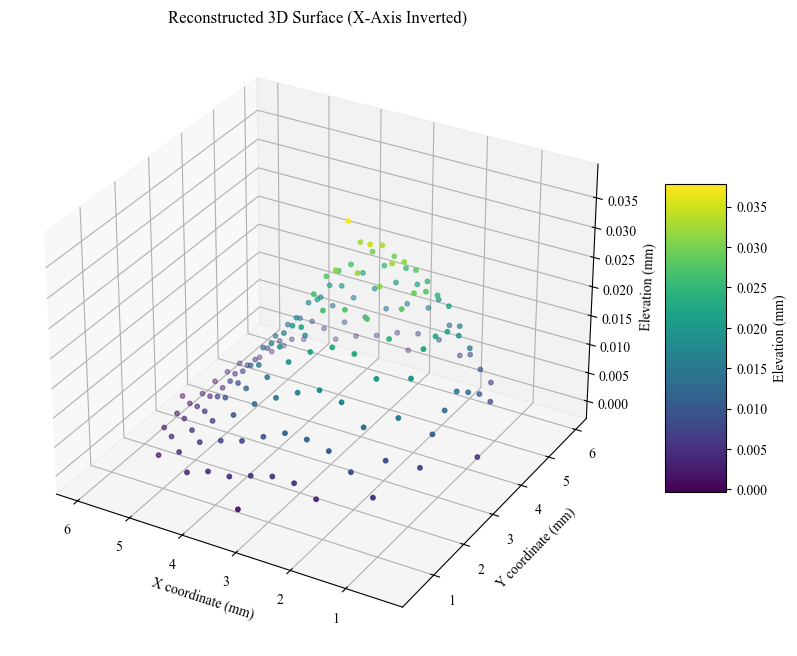

In [72]:

x_axis = np.arange(0, nc) * p
y_axis = np.arange(0, nr) * p
X, Y = np.meshgrid(x_axis, y_axis)

# --- 2. Flatten ALL Data for Masking ---
x_flat = X.flatten()
y_flat = Y.flatten()
z_flat = Z.flatten()
valid_flat = valid_points.flatten()

# --- 3. Create the Boolean Mask ---
mask = (valid_flat == 1)

# --- 4. Apply the Mask to Your Data ---
x_valid = x_flat[mask]
y_valid = y_flat[mask]
z_valid = z_flat[mask]

# --- 5. Set up the 3D Plot ---
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# --- 6. Plot the VALID Points ---
scatter_plot = ax.scatter(x_valid, y_valid, z_valid, c=z_valid, cmap='viridis', s=10)

# --- 7. Add Labels and a Color Bar ---
ax.set_xlabel('X coordinate (mm)')
ax.set_ylabel('Y coordinate (mm)')
ax.set_zlabel('Elevation (mm)')
ax.set_title('Reconstructed 3D Surface (X-Axis Inverted)')
fig.colorbar(scatter_plot, shrink=0.5, aspect=5, label='Elevation (mm)')

# --- 8. Manually Invert X-Axis (THE CHANGE IS HERE) ---
# Get the current x-axis limits
current_xlim = ax.get_xlim()
# Set the x-axis limits in reverse order
ax.set_xlim(current_xlim[1], current_xlim[0])
# The y-axis will remain in its default orientation

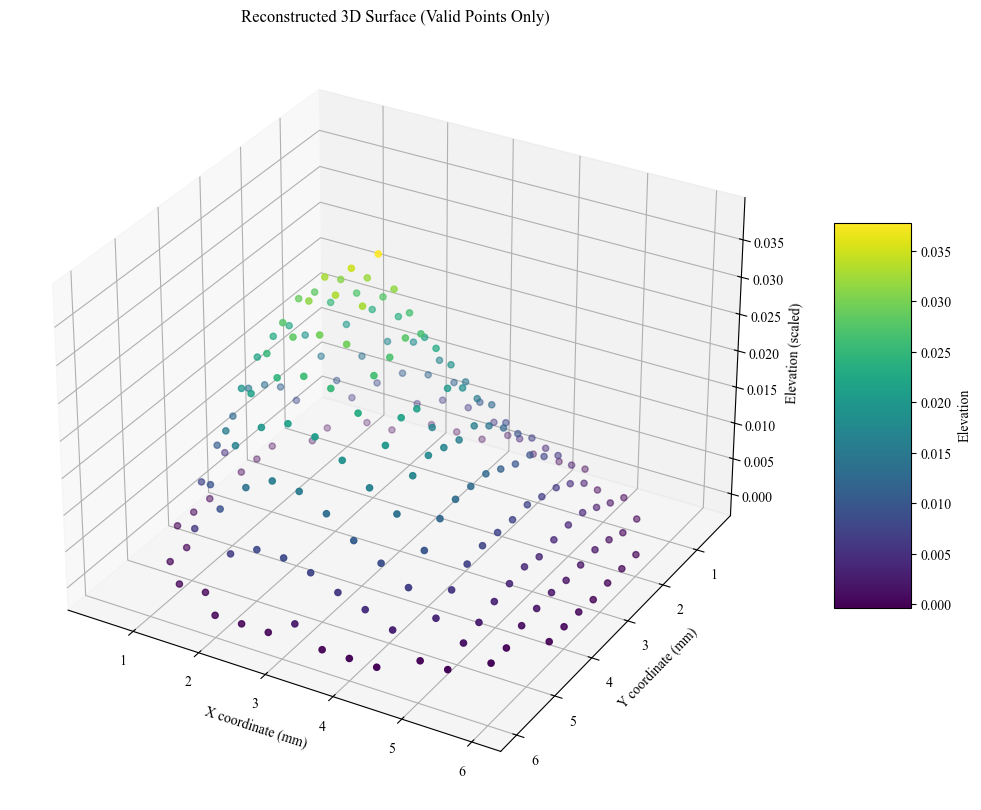

In [73]:
x_axis = np.arange(0, nc) * p
y_axis = np.arange(0, nr) * p

X, Y = np.meshgrid(x_axis, y_axis)

# --- 2. Flatten ALL Data ---
x_flat = X.flatten()
y_flat = Y.flatten()
z_flat = Z.flatten()
f_flat = f.flatten() # Flatten the 'f' (filled) matrix

mask = f_flat > 0


x_valid = x_flat[mask]
y_valid = y_flat[mask]
z_valid = z_flat[mask]

fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

surf = ax.scatter(x_valid, y_valid, z_valid, c= z_valid, cmap='viridis')


ax.invert_xaxis() 

current_xlim = ax.get_xlim()
current_ylim = ax.get_ylim()

# Set the limits in reverse order
ax.set_xlim(current_xlim[1], current_xlim[0])
ax.set_ylim(current_ylim[1], current_ylim[0])

ax.set_xlabel('X coordinate (mm)')
ax.set_ylabel('Y coordinate (mm)')
ax.set_zlabel('Elevation (scaled)') # Added 'scaled'
ax.set_title('Reconstructed 3D Surface (Valid Points Only)')
fig.colorbar(surf, shrink=0.5, aspect=5, label='Elevation')